# 04 — Model Interpretation and Chemical Insights

## Overview

Notebook 03 established that nonlinear tree-based models substantially outperformed the reduced linear QSAR model in predicting Nav1.7 inhibitory potency. XGBoost achieved the strongest overall held-out performance (**R² = 0.549, RMSE = 0.708 pIC₅₀ units**), although Random Forest produced comparable predictive performance.

This notebook shifts the focus from **predictive performance to chemical interpretation and discovery**.

The primary objective is to investigate what relationships the validated XGBoost model learned between molecular properties and Nav1.7 inhibitory potency. Rather than treating the model solely as a prediction tool, model-explanation methods are used to identify important molecular descriptors and characterize nonlinear, threshold-dependent, and potentially interacting relationships that may not be apparent from pairwise correlations or linear QSAR analysis.

The seven chemistry-informed descriptors examined are:

- Molecular Weight (MW)
- LogP
- Topological Polar Surface Area (TPSA)
- Hydrogen-Bond Donors (HBD)
- Rotatable Bonds
- Ring Count
- Fraction Csp³

SHAP (SHapley Additive exPlanations) is used as the primary model-interpretation framework. SHAP values quantify how individual descriptor values shift XGBoost predictions relative to the model's baseline prediction, allowing both the magnitude and direction of descriptor effects to be investigated.

Because the primary goal is **chemical relationship discovery across the available Nav1.7 chemical space**, the main SHAP analyses are performed across the complete **6,738-compound modeling dataset**. This provides greater coverage of descriptor values and improves the ability to examine nonlinear trends, transitions, and potential descriptor interactions.

The XGBoost model itself remains trained exclusively on the original **5,390-compound training set**. The **1,348 held-out test compounds are not used for model fitting** and retain their role in independent model validation. SHAP patterns observed across the full dataset are additionally compared with those obtained from the held-out test set to assess whether the principal interpretation patterns persist in compounds excluded from model training.

The interpretation workflow addresses four related questions:

1. **Which molecular descriptors contribute most strongly to XGBoost predictions of Nav1.7 inhibitory potency?**
2. **How does each important descriptor influence predicted pIC₅₀ across its observed chemical range?**
3. **Are important descriptor effects nonlinear, threshold-dependent, or influenced by interactions with other molecular properties?**
4. **How do the relationships identified by XGBoost compare with the correlations, linear QSAR coefficients, and Random Forest feature-importance patterns observed in earlier analyses?**

Particular attention is given to descriptors whose nonlinear importance differs from their simple linear association with potency. **Fraction Csp³** is especially notable because its weak pairwise relationship with pIC₅₀ contrasts with its substantial importance in the Random Forest model, suggesting that its predictive contribution may depend on nonlinear effects or interactions with other molecular properties.

All SHAP-derived relationships are interpreted as **model-derived predictive associations rather than direct evidence of biological causality or molecular mechanism**. The seven descriptors provide broad physicochemical and structural summaries but do not explicitly encode detailed molecular connectivity, binding interactions, ionization states, stereochemistry, or protein-ligand interactions.

The goal of this notebook is therefore not to claim a complete mechanistic explanation of Nav1.7 inhibition, but to use the validated nonlinear model as a tool for identifying **chemically meaningful patterns and hypotheses that can guide deeper structure-activity analysis**.

## 1. Load and Verify Interpretation Dataset

The finalized modeling dataset exported from Notebook 03 is loaded to establish the data foundation for model interpretation.

The dataset contains **6,738 GOOD-quality compounds** with experimental pIC₅₀ values and the seven chemistry-informed molecular descriptors used consistently during model development:

- Molecular Weight (MW)
- LogP
- Topological Polar Surface Area (TPSA)
- Hydrogen-Bond Donors (HBD)
- Rotatable Bonds
- Ring Count
- Fraction Csp³

Compound identifiers and canonical SMILES are retained to connect descriptor-level model behavior with individual molecular structures when needed.

The original **training/test assignment from Notebook 03 is also preserved**. This maintains the same 5,390-compound training set and 1,348-compound held-out test set used during model validation and prevents the interpretation workflow from introducing a new data split.

Before reconstructing the XGBoost model, the imported dataset is verified for dataset dimensions, expected columns, missing values, and train/test counts. This ensures that Notebook 04 begins with the same finalized chemical feature space and experimental design established in Notebook 03.

In [2]:

# ============================================================
# GLOBAL PLOT COLOR SCHEME
# ============================================================

# Primary plotting colors
COLOR_PRIMARY = '#4C78A8'      # Main blue
COLOR_SECONDARY = '#72A0C1'    # Secondary/light blue
COLOR_DARK = '#304F5B'         # Dark slate
COLOR_TREND = '#555555'        # Regression/trend lines
COLOR_ERROR = '#222222'        # Error bars and outlines

# Potency progression: weak → very potent
POTENCY_COLORS = [
    '#B8C9D6',   # Weak
    '#8EABC0',   # Medium
    '#5F83A3',   # Potent
    '#304F5B'    # Very Potent
]

In [3]:
# ============================================================
# 1. Load and Verify Interpretation Dataset
# ============================================================

import pandas as pd
import io
from google.colab import files

# 1. Upload the interpretation dataset exported from Notebook 03
print("Upload: nav17_model_interpretation_data.csv")

uploaded = files.upload()

# 2. Identify the uploaded file
file_name = list(uploaded.keys())[0]

# 3. Load the dataset
interpretation_df = pd.read_csv(
    io.BytesIO(uploaded[file_name])
)

# 4. Basic dataset audit
print("\n--- Interpretation Dataset Audit ---")
print(f"Loaded file:        {file_name}")
print(f"Total compounds:    {len(interpretation_df):,}")
print(f"Number of columns:  {interpretation_df.shape[1]}")

print(
    f"Training compounds: "
    f"{(interpretation_df['DatasetSplit'] == 'Train').sum():,}"
)

print(
    f"Test compounds:     "
    f"{(interpretation_df['DatasetSplit'] == 'Test').sum():,}"
)

print("\nColumns:")
print(interpretation_df.columns.tolist())

print("\nMissing values:")
print(interpretation_df.isnull().sum())

# 5. Preview
display(interpretation_df.head())

Upload: nav17_model_interpretation_data.csv


Saving nav17_model_interpretation_data.csv to nav17_model_interpretation_data.csv

--- Interpretation Dataset Audit ---
Loaded file:        nav17_model_interpretation_data.csv
Total compounds:    6,738
Number of columns:  11
Training compounds: 5,390
Test compounds:     1,348

Columns:
['molecule_chembl_id', 'canonical_smiles', 'pIC50', 'MW', 'LogP', 'TPSA', 'HBD', 'RotatableBonds', 'RingCount', 'FractionCSP3', 'DatasetSplit']

Missing values:
molecule_chembl_id    0
canonical_smiles      0
pIC50                 0
MW                    0
LogP                  0
TPSA                  0
HBD                   0
RotatableBonds        0
RingCount             0
FractionCSP3          0
DatasetSplit          0
dtype: int64


,molecule_chembl_id,canonical_smiles,pIC50,MW,LogP,TPSA,HBD,RotatableBonds,RingCount,FractionCSP3,DatasetSplit
0,CHEMBL3904041,C#Cc1cccc(OC2CN(c3ncnc(Nc4cccc(C(=O)NC)c4)n3)C...,6.004365,400.164774,2.2237,92.27,2.0,6.0,4.0,0.181818,Train
1,CHEMBL3662199,C/C=C/c1cc(C(=O)NS(=O)(=O)N2CCC2)c(F)cc1OCC12C...,8.221849,462.198857,4.1343,75.71,1.0,7.0,6.0,0.625000,Train
2,CHEMBL190461,C=C(C)[C@@H]1CCC(C)=C[C@H]1c1c(O)cc(CCCCC)cc1O,5.739929,314.224580,5.8465,40.46,2.0,6.0,2.0,0.523810,Train
3,CHEMBL3955581,C=C(C)c1ccccc1N1CCOc2cc(S(=O)(=O)Nc3nccs3)ccc21,5.616185,413.086783,4.5075,71.53,1.0,5.0,4.0,0.150000,Train
4,CHEMBL5805169,C=C(C)c1cn2c(NS(C)(=O)=O)nnc2cc1OCC12CC3CC(CC(...,7.291579,416.188212,3.7291,85.59,1.0,6.0,6.0,0.619048,Train


### Dataset Verification

The interpretation dataset was successfully loaded with **6,738 compounds and 11 columns**. The original Notebook 03 partition was preserved exactly, containing **5,390 training compounds** and **1,348 held-out test compounds**.

All seven finalized molecular descriptors, experimental pIC₅₀ values, compound identifiers, canonical SMILES, and dataset assignments were present with **no missing values**.

The verified dataset therefore reproduces the finalized modeling feature space and train/test structure established in Notebook 03 and can be used directly for model reconstruction and interpretation.

## 2. Reconstruct Final XGBoost Model

The final XGBoost QSAR model established in Notebook 03 is reconstructed using the preserved training/test assignments and the same seven chemistry-informed molecular descriptors.

The model is trained exclusively on the **5,390 compounds assigned to the training set**, while the **1,348 held-out test compounds remain excluded from model fitting**.

To reproduce the finalized modeling framework, the XGBoost hyperparameters are kept identical to those used in Notebook 03:

- **Number of trees (`n_estimators`) = 100**
- **Learning rate = 0.1**
- **Maximum tree depth = 6**
- **Random state = 42**

No additional feature selection, hyperparameter optimization, or model tuning is performed in this notebook.

Before beginning model interpretation, the reconstructed model is evaluated on the preserved held-out test set. Its R², RMSE, and MAE are compared with the final Notebook 03 results to verify that the same predictive model has been successfully reproduced.

Once model performance is confirmed, the reconstructed XGBoost model serves as the basis for the subsequent SHAP analyses.

In [4]:
# ============================================================
# 2. Reconstruct Final XGBoost Model
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
from xgboost import XGBRegressor


# ------------------------------------------------------------
# 1. Define the exact seven descriptors used in Notebook 03
# ------------------------------------------------------------

reduced_descriptors = [
    'MW',
    'LogP',
    'TPSA',
    'HBD',
    'RotatableBonds',
    'RingCount',
    'FractionCSP3'
]


# ------------------------------------------------------------
# 2. Reconstruct X and y from the complete 6,738-row dataset
#    in the original saved row order
# ------------------------------------------------------------

X = interpretation_df[reduced_descriptors].copy()
y = interpretation_df['pIC50'].copy()

print("--- Complete Modeling Dataset ---")
print(f"Compounds:   {len(X):,}")
print(f"Descriptors: {X.shape[1]}")
print(f"Features:    {X.columns.tolist()}")


# ------------------------------------------------------------
# 3. Reproduce the EXACT Notebook 03 train/test split
# ------------------------------------------------------------

X_train_reduced, X_test_reduced, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n--- Reconstructed Train/Test Split ---")
print(f"Training compounds: {len(X_train_reduced):,}")
print(f"Test compounds:     {len(X_test_reduced):,}")


# ------------------------------------------------------------
# 4. Verify reconstructed membership against DatasetSplit
# ------------------------------------------------------------

saved_train_indices = set(
    interpretation_df.index[
        interpretation_df['DatasetSplit'] == 'Train'
    ]
)

saved_test_indices = set(
    interpretation_df.index[
        interpretation_df['DatasetSplit'] == 'Test'
    ]
)

reconstructed_train_indices = set(X_train_reduced.index)
reconstructed_test_indices = set(X_test_reduced.index)

train_match = (
    saved_train_indices == reconstructed_train_indices
)

test_match = (
    saved_test_indices == reconstructed_test_indices
)

print("\n--- Split Membership Verification ---")
print(f"Training membership matches saved split: {train_match}")
print(f"Test membership matches saved split:     {test_match}")

assert train_match, \
    "Reconstructed training membership does not match saved DatasetSplit."

assert test_match, \
    "Reconstructed test membership does not match saved DatasetSplit."


# ------------------------------------------------------------
# 5. Reconstruct exact Notebook 03 XGBoost model
# ------------------------------------------------------------

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

print("\nTraining reconstructed XGBoost model...")

xgb_model.fit(
    X_train_reduced,
    y_train
)

print("Training complete.")


# ------------------------------------------------------------
# 6. Generate predictions on the reconstructed held-out set
# ------------------------------------------------------------

xgb_test_pred = xgb_model.predict(
    X_test_reduced
)


# ------------------------------------------------------------
# 7. Calculate held-out metrics
# ------------------------------------------------------------

xgb_test_r2 = r2_score(
    y_test,
    xgb_test_pred
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_test_pred
    )
)

xgb_test_mae = mean_absolute_error(
    y_test,
    xgb_test_pred
)


# ------------------------------------------------------------
# 8. Report results at higher precision
# ------------------------------------------------------------

print("\n--- Reconstructed XGBoost Held-Out Performance ---")
print(f"R²:   {xgb_test_r2:.6f}")
print(f"RMSE: {xgb_test_rmse:.6f} pIC₅₀ units")
print(f"MAE:  {xgb_test_mae:.6f} pIC₅₀ units")

--- Complete Modeling Dataset ---
Compounds:   6,738
Descriptors: 7
Features:    ['MW', 'LogP', 'TPSA', 'HBD', 'RotatableBonds', 'RingCount', 'FractionCSP3']

--- Reconstructed Train/Test Split ---
Training compounds: 5,390
Test compounds:     1,348

--- Split Membership Verification ---
Training membership matches saved split: True
Test membership matches saved split:     True

Training reconstructed XGBoost model...
Training complete.

--- Reconstructed XGBoost Held-Out Performance ---
R²:   0.549123
RMSE: 0.708427 pIC₅₀ units
MAE:  0.538847 pIC₅₀ units


### Model Reconstruction Verification

The finalized XGBoost model was successfully reconstructed using the original seven-descriptor feature space, 80/20 train-test split, and fixed model configuration established in Notebook 03.

Reapplying the original `train_test_split` procedure with `random_state=42` reproduced both the exact training/test membership and the original shuffled row ordering. The reconstructed model achieved a held-out **R² of 0.549**, **RMSE of 0.708 pIC₅₀ units**, and **MAE of 0.539 pIC₅₀ units**, reproducing the final performance reported in Notebook 03.

The model is therefore considered successfully reconstructed and is retained without further fitting or parameter modification for all subsequent interpretation analyses.

## 3. Global SHAP Analysis

SHAP (SHapley Additive exPlanations) analysis was used to examine how the seven molecular descriptors contribute to predictions generated by the validated XGBoost model.

For each compound, SHAP assigns a contribution value to every descriptor relative to the model's baseline prediction. A **positive SHAP value** indicates that a descriptor contributes toward a higher predicted pIC₅₀, whereas a **negative SHAP value** indicates a contribution toward a lower predicted pIC₅₀. The magnitude of the SHAP value reflects the strength of that descriptor's contribution to an individual prediction.

Because the primary objective of this notebook is **chemical interpretation and relationship discovery**, the main global SHAP analysis is performed across the complete **6,738-compound modeling dataset**. Using the full dataset provides broader coverage of the molecular descriptor space and allows model-derived chemical relationships to be examined across the complete collection of Nav1.7 inhibitors included in this study.

Global SHAP analysis evaluates two complementary aspects of model behavior:

- **Global descriptor importance**, measured using mean absolute SHAP values (mean |SHAP|), which quantify the average magnitude of each descriptor's contribution to model predictions.
- **Direction and distribution of descriptor effects**, examined using the SHAP summary plot, which relates low and high descriptor values to their positive or negative contributions to predicted pIC₅₀.

The resulting descriptor ranking provides a model-based measure of which physicochemical and structural properties most strongly influence XGBoost predictions. The distribution of SHAP values additionally reveals whether high or low values of a descriptor tend to increase or decrease predicted potency and whether its effects appear uniform or heterogeneous across chemical space.

Because **5,390 of the 6,738 compounds were used to train the XGBoost model**, full-dataset SHAP results are interpreted as descriptions of relationships learned by the model rather than as independent evidence of generalization. To assess the robustness of these interpretations, global SHAP importance is additionally calculated for the **1,348 held-out test compounds** and compared with the full-dataset descriptor ranking.

Agreement between the full-dataset and held-out SHAP patterns would indicate that the principal descriptor relationships learned by XGBoost are also expressed when the model is applied to compounds excluded from training.

Global SHAP importance is interpreted as **predictive association rather than biological causality**. These results establish the major descriptor-level patterns learned by XGBoost and provide the foundation for subsequent analyses of nonlinear relationships, descriptor-specific effects, and potential chemical interactions.

### 3.1 Global SHAP Feature Importance

Global feature importance was quantified using the mean absolute SHAP value for each molecular descriptor across the complete 6,738-compound dataset.

Mean |SHAP| measures the average magnitude of a descriptor's contribution to XGBoost predictions, regardless of whether that contribution increases or decreases predicted pIC₅₀. Descriptors with larger mean |SHAP| values therefore exert a greater overall influence on model predictions.

This analysis provides a model-based ranking of the seven molecular descriptors and identifies the properties that should receive the greatest attention in subsequent chemical interpretation. Because mean |SHAP| measures contribution magnitude rather than direction, the direction and distribution of these effects are examined separately in the SHAP summary and descriptor-dependence analyses.

--- Global SHAP Analysis Dataset ---
Compounds:   6,738
Descriptors: 7
Features:    ['MW', 'LogP', 'TPSA', 'HBD', 'RotatableBonds', 'RingCount', 'FractionCSP3']

Calculating SHAP values for the complete dataset...
SHAP calculation complete.
SHAP matrix dimensions: (6738, 7)

Maximum SHAP reconstruction error: 0.00000429

--- Global XGBoost SHAP Feature Importance ---


,Descriptor,MeanAbsSHAP,RelativeImportance (%)
0,MW,0.3659,37.0
1,FractionCSP3,0.1752,17.7
2,LogP,0.1279,12.9
3,TPSA,0.1054,10.7
4,RotatableBonds,0.0811,8.2
5,HBD,0.0713,7.2
6,RingCount,0.0613,6.2


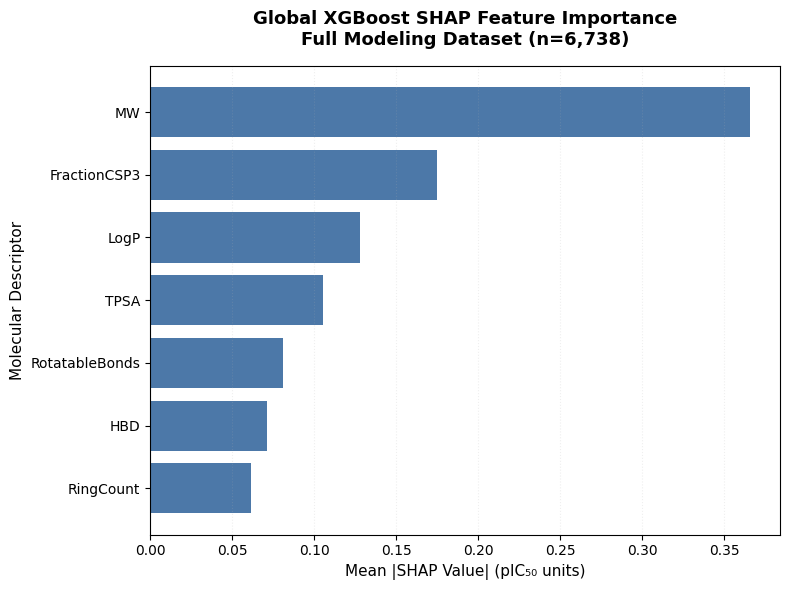

In [5]:
# ============================================================
# 3.1 Global SHAP Feature Importance
# Full Modeling Dataset (n = 6,738)
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Construct the complete descriptor matrix
# ------------------------------------------------------------

X_full = interpretation_df[reduced_descriptors].copy()

print("--- Global SHAP Analysis Dataset ---")
print(f"Compounds:   {len(X_full):,}")
print(f"Descriptors: {X_full.shape[1]}")
print(f"Features:    {X_full.columns.tolist()}")


# ------------------------------------------------------------
# 2. Create SHAP TreeExplainer
# ------------------------------------------------------------

# Uses the finalized XGBoost model reconstructed in Section 2.
# The model is NOT refitted here.

explainer = shap.TreeExplainer(xgb_model)


# ------------------------------------------------------------
# 3. Calculate SHAP values for all 6,738 compounds
# ------------------------------------------------------------

print("\nCalculating SHAP values for the complete dataset...")

shap_values_full = explainer(X_full)

print("SHAP calculation complete.")
print(
    f"SHAP matrix dimensions: "
    f"{shap_values_full.values.shape}"
)


# ------------------------------------------------------------
# 4. Verify SHAP additive consistency
# ------------------------------------------------------------

# For each compound:
# baseline prediction + sum(SHAP contributions)
# should reproduce the XGBoost prediction.

shap_reconstructed_pred = (
    shap_values_full.base_values
    + shap_values_full.values.sum(axis=1)
)

xgb_full_pred = xgb_model.predict(X_full)

max_shap_error = np.max(
    np.abs(
        shap_reconstructed_pred
        - xgb_full_pred
    )
)

print(
    "\nMaximum SHAP reconstruction error: "
    f"{max_shap_error:.8f}"
)


# ------------------------------------------------------------
# 5. Calculate mean absolute SHAP importance
# ------------------------------------------------------------

mean_abs_shap_full = np.abs(
    shap_values_full.values
).mean(axis=0)

shap_importance_full = pd.DataFrame({
    'Descriptor': X_full.columns,
    'MeanAbsSHAP': mean_abs_shap_full
})

shap_importance_full = (
    shap_importance_full
    .sort_values(
        by='MeanAbsSHAP',
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Add relative contribution percentage
# ------------------------------------------------------------

shap_importance_full['RelativeImportance (%)'] = (
    shap_importance_full['MeanAbsSHAP']
    / shap_importance_full['MeanAbsSHAP'].sum()
    * 100
)


# ------------------------------------------------------------
# 7. Display global importance table
# ------------------------------------------------------------

print("\n--- Global XGBoost SHAP Feature Importance ---")

display(
    shap_importance_full.style.format({
        'MeanAbsSHAP': '{:.4f}',
        'RelativeImportance (%)': '{:.1f}'
    })
)


# ------------------------------------------------------------
# 8. Plot global mean |SHAP| importance
# ------------------------------------------------------------

# Reverse order for horizontal bar chart so the
# most important descriptor appears at the top.

plot_df = shap_importance_full.sort_values(
    by='MeanAbsSHAP',
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_df['Descriptor'],
    plot_df['MeanAbsSHAP'],
    color=COLOR_PRIMARY
)

plt.xlabel(
    "Mean |SHAP Value| (pIC₅₀ units)",
    fontsize=11
)

plt.ylabel(
    "Molecular Descriptor",
    fontsize=11
)

plt.title(
    "Global XGBoost SHAP Feature Importance\n"
    "Full Modeling Dataset (n=6,738)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    axis='x',
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()

#### Global SHAP Importance Results

Global SHAP analysis identified substantial differences in the contributions of the seven molecular descriptors to XGBoost predictions.

**Molecular Weight (MW)** was the dominant descriptor, with a mean absolute SHAP value of **0.3659 pIC₅₀ units**, accounting for approximately **37.0%** of the total mean absolute SHAP importance. **Fraction Csp³** ranked second (**17.7%**), followed by **LogP** (**12.9%**) and **TPSA** (**10.7%**). Rotatable Bonds, HBD, and Ring Count showed smaller but measurable contributions.

The ranking of **MW > Fraction Csp³ > LogP** is consistent with the leading descriptor ranking observed independently in the Random Forest feature-importance analysis in Notebook 03. This agreement across two different tree-based modeling approaches suggests that these molecular properties represent important sources of predictive information within the selected descriptor space.

Fraction Csp³ is particularly notable because its strong nonlinear model importance contrasts with its relatively weak simple association with experimental pIC₅₀ observed during exploratory analysis. This suggests that its contribution may involve **nonlinear behavior, interactions with other molecular properties, or effects restricted to particular regions of chemical space**.

Mean |SHAP| measures the magnitude of descriptor contributions but does not indicate whether high or low descriptor values increase predicted potency. The direction and distribution of these effects are therefore examined next using the SHAP summary plot.

### 3.2 SHAP Summary Plot

The global mean |SHAP| analysis identifies which molecular descriptors contribute most strongly to XGBoost predictions, but it does not show the **direction of those contributions**. A SHAP summary plot was therefore used to examine how low and high descriptor values influence predicted Nav1.7 inhibitory potency across the complete 6,738-compound dataset.

Each point in the summary plot represents one compound and one molecular descriptor. Its horizontal position represents the descriptor's **SHAP value**, or its contribution to the predicted pIC₅₀:

- **Positive SHAP values** shift the prediction toward higher pIC₅₀ and therefore greater predicted potency.
- **Negative SHAP values** shift the prediction toward lower pIC₅₀ and therefore lower predicted potency.

Point color represents the underlying descriptor value, ranging from relatively **low to high values**. The combination of position and color therefore reveals whether high or low values of a molecular property tend to increase or decrease predicted potency.

Unlike a linear regression coefficient, the SHAP distribution does not assume that a descriptor has a single constant effect across all compounds. A descriptor may produce positive contributions in one region of chemical space and negative contributions in another. Broad, asymmetric, or mixed SHAP distributions can therefore provide initial evidence of **nonlinear behavior, thresholds, or interactions with other molecular properties**.

The summary plot is used primarily to identify these global directional patterns. Detailed relationships between individual descriptor values and their SHAP contributions are examined subsequently using descriptor-specific dependence analyses.

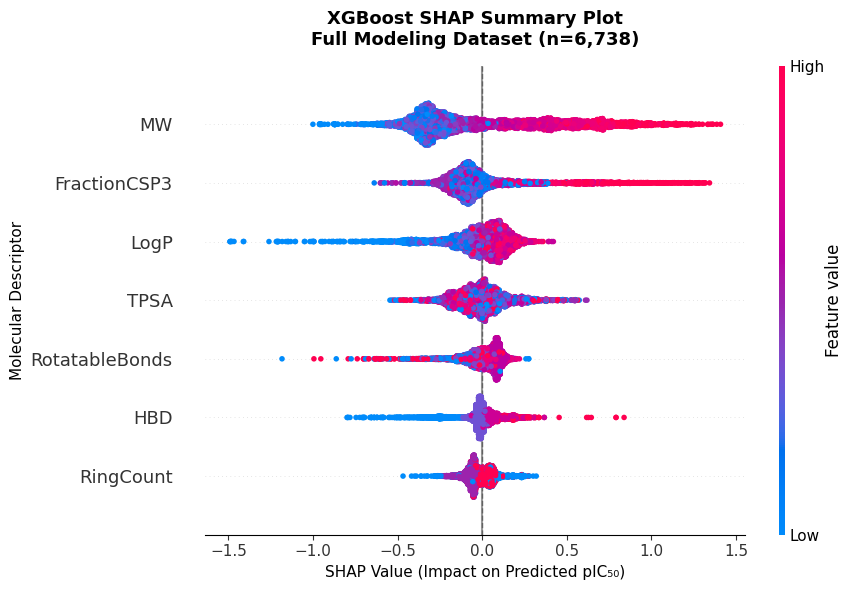

In [6]:
# ============================================================
# 3.2 SHAP Summary Plot
# Full Modeling Dataset (n = 6,738)
# ============================================================

import shap
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Generate SHAP summary / beeswarm plot
# ------------------------------------------------------------

# Uses:
# - shap_values_full calculated in Section 3.1
# - X_full containing all 6,738 compounds
#
# Each point represents one compound.
# Horizontal position = SHAP contribution to predicted pIC50
# Color = underlying descriptor value (low → high)

shap.summary_plot(
    shap_values_full.values,
    X_full,
    feature_names=X_full.columns,
    plot_type="dot",
    max_display=7,
    show=False,
    plot_size=(9, 6)
)


# ------------------------------------------------------------
# 2. Customize plot labels
# ------------------------------------------------------------

plt.title(
    "XGBoost SHAP Summary Plot\n"
    "Full Modeling Dataset (n=6,738)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "SHAP Value (Impact on Predicted pIC₅₀)",
    fontsize=11
)

plt.ylabel(
    "Molecular Descriptor",
    fontsize=11
)


# ------------------------------------------------------------
# 3. Add reference line at SHAP = 0
# ------------------------------------------------------------

plt.axvline(
    x=0,
    color=COLOR_TREND,
    linestyle='--',
    linewidth=1,
    alpha=0.8
)


# ------------------------------------------------------------
# 4. Final formatting
# ------------------------------------------------------------

plt.tight_layout()
plt.show()

#### SHAP Summary Results

The SHAP summary plot reveals substantial differences in both the magnitude and direction of descriptor effects across the full modeling dataset.

**Molecular Weight (MW)** shows the strongest directional pattern. Lower MW values are predominantly associated with negative SHAP contributions, whereas higher MW values extend strongly into positive SHAP values. Within the XGBoost model, increasing molecular size is therefore generally associated with increased predicted pIC₅₀, although the distribution indicates that the magnitude of this effect varies among compounds.

**Fraction Csp³** also shows a pronounced but more heterogeneous relationship. Higher Fraction Csp³ values can produce strongly positive SHAP contributions, while substantial overlap remains near zero. This pattern is consistent with the possibility that the influence of three-dimensional carbon character is nonlinear or dependent on other molecular properties.

For **LogP**, very low values are associated with some of the strongest negative SHAP contributions observed in the dataset. Higher LogP values tend to shift contributions toward zero or positive values, although considerable overlap suggests that lipophilicity does not exert a uniform effect across all compounds.

**TPSA** displays a more mixed distribution, with both low and high values occurring on either side of zero. This suggests that the contribution of molecular polarity may depend more strongly on chemical context or interactions with other descriptors.

**Rotatable Bonds** and **HBD** generally make smaller contributions than the leading descriptors, but both show asymmetric patterns. In particular, some compounds with greater flexibility receive strongly negative contributions, while low HBD values are associated with an extended negative SHAP distribution. **Ring Count** exhibits the narrowest overall SHAP distribution, consistent with its lower global importance.

Together, these results show that the nonlinear XGBoost model does not treat the molecular descriptors as having uniform additive effects. Several descriptors exhibit asymmetric, overlapping, or potentially threshold-dependent SHAP distributions, motivating descriptor-specific dependence analysis to determine how their contributions change across their actual numerical ranges.

### 3.3 Held-Out SHAP Robustness Check

The primary SHAP analyses were performed across the complete 6,738-compound dataset to maximize coverage of the chemical descriptor space. However, because 5,390 of these compounds were used to train the XGBoost model, an additional analysis was performed using only the **1,348 held-out test compounds**.

The purpose of this analysis is not to reevaluate predictive performance, which was established in Notebook 03, but to determine whether the principal descriptor-importance patterns identified across the full dataset are also observed among compounds that were excluded from model training.

Mean absolute SHAP values are calculated separately for the held-out test set and compared with the full-dataset results. Particular attention is given to:

- whether the overall descriptor ranking remains similar,
- whether the leading descriptors retain comparable relative importance, and
- whether any descriptor shows a substantial change in importance when analysis is restricted to unseen compounds.

Strong agreement between the two SHAP rankings would indicate that the major interpretation patterns are not confined to the compounds used during model fitting. Conversely, substantial differences could indicate that some learned relationships are more specific to the training chemical space.

This comparison therefore serves as a **robustness check for the global model interpretation** before proceeding to detailed descriptor-specific chemical analysis.

--- Held-Out SHAP Dataset ---
Test compounds: 1,348
Descriptors:    7
Features:       ['MW', 'LogP', 'TPSA', 'HBD', 'RotatableBonds', 'RingCount', 'FractionCSP3']

Calculating SHAP values for held-out test compounds...
SHAP calculation complete.
SHAP matrix dimensions: (1348, 7)

--- Full Dataset vs. Held-Out SHAP Importance ---


,Descriptor,FullMeanAbsSHAP,TestMeanAbsSHAP,FullRelative (%),TestRelative (%),FullRank,TestRank,RankChange
0,MW,0.3659,0.3592,37.0,36.7,1,1,+0
1,FractionCSP3,0.1752,0.1764,17.7,18.0,2,2,+0
2,LogP,0.1279,0.1277,12.9,13.0,3,3,+0
3,TPSA,0.1054,0.0997,10.7,10.2,4,4,+0
4,RotatableBonds,0.0811,0.0804,8.2,8.2,5,5,+0
5,HBD,0.0713,0.0736,7.2,7.5,6,6,+0
6,RingCount,0.0613,0.0622,6.2,6.4,7,7,+0



Spearman rank correlation (Full vs. Test): 1.000


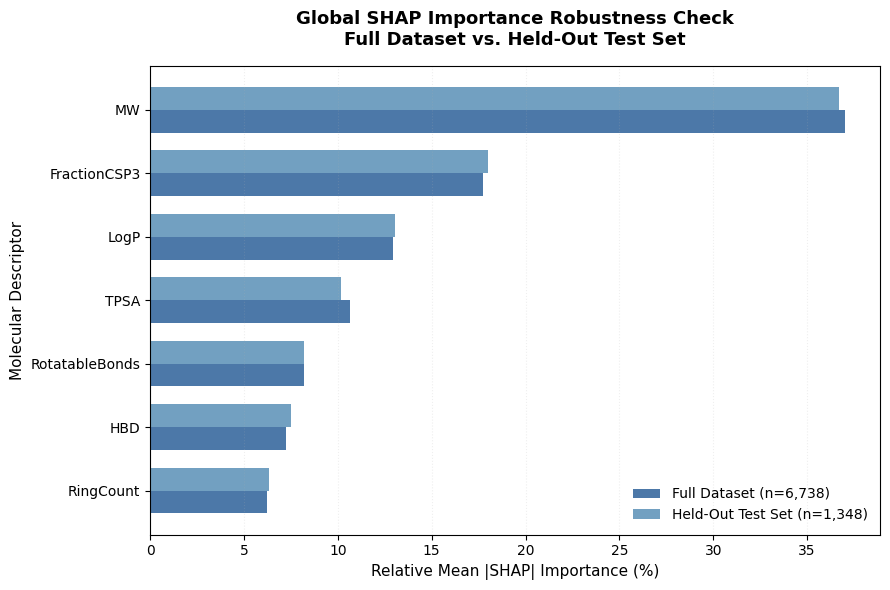

In [7]:
# ============================================================
# 3.3 Held-Out SHAP Robustness Check
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Use the exact held-out test set reconstructed in Section 2
# ------------------------------------------------------------

X_shap_test = X_test_reduced.copy()

print("--- Held-Out SHAP Dataset ---")
print(f"Test compounds: {len(X_shap_test):,}")
print(f"Descriptors:    {X_shap_test.shape[1]}")
print(f"Features:       {X_shap_test.columns.tolist()}")


# ------------------------------------------------------------
# 2. Calculate SHAP values for held-out compounds
# ------------------------------------------------------------

# Reuse the TreeExplainer created in Section 3.1.
# The XGBoost model is NOT refitted.

print("\nCalculating SHAP values for held-out test compounds...")

shap_values_test = explainer(X_shap_test)

print("SHAP calculation complete.")
print(
    f"SHAP matrix dimensions: "
    f"{shap_values_test.values.shape}"
)


# ------------------------------------------------------------
# 3. Calculate held-out mean absolute SHAP importance
# ------------------------------------------------------------

mean_abs_shap_test = np.abs(
    shap_values_test.values
).mean(axis=0)

shap_importance_test = pd.DataFrame({
    'Descriptor': X_shap_test.columns,
    'TestMeanAbsSHAP': mean_abs_shap_test
})


# ------------------------------------------------------------
# 4. Combine with full-dataset SHAP results from Section 3.1
# ------------------------------------------------------------

shap_robustness_df = (
    shap_importance_full[
        ['Descriptor', 'MeanAbsSHAP']
    ]
    .rename(
        columns={
            'MeanAbsSHAP': 'FullMeanAbsSHAP'
        }
    )
    .merge(
        shap_importance_test,
        on='Descriptor'
    )
)


# ------------------------------------------------------------
# 5. Calculate relative importance within each dataset
# ------------------------------------------------------------

shap_robustness_df['FullRelative (%)'] = (
    shap_robustness_df['FullMeanAbsSHAP']
    / shap_robustness_df['FullMeanAbsSHAP'].sum()
    * 100
)

shap_robustness_df['TestRelative (%)'] = (
    shap_robustness_df['TestMeanAbsSHAP']
    / shap_robustness_df['TestMeanAbsSHAP'].sum()
    * 100
)


# ------------------------------------------------------------
# 6. Calculate rank in each dataset
# ------------------------------------------------------------

shap_robustness_df['FullRank'] = (
    shap_robustness_df['FullMeanAbsSHAP']
    .rank(
        ascending=False,
        method='min'
    )
    .astype(int)
)

shap_robustness_df['TestRank'] = (
    shap_robustness_df['TestMeanAbsSHAP']
    .rank(
        ascending=False,
        method='min'
    )
    .astype(int)
)

shap_robustness_df['RankChange'] = (
    shap_robustness_df['TestRank']
    - shap_robustness_df['FullRank']
)


# ------------------------------------------------------------
# 7. Sort by full-dataset importance
# ------------------------------------------------------------

shap_robustness_df = (
    shap_robustness_df
    .sort_values(
        'FullMeanAbsSHAP',
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. Display comparison table
# ------------------------------------------------------------

print("\n--- Full Dataset vs. Held-Out SHAP Importance ---")

display(
    shap_robustness_df.style.format({
        'FullMeanAbsSHAP': '{:.4f}',
        'TestMeanAbsSHAP': '{:.4f}',
        'FullRelative (%)': '{:.1f}',
        'TestRelative (%)': '{:.1f}',
        'RankChange': '{:+d}'
    })
)


# ------------------------------------------------------------
# 9. Calculate rank agreement
# ------------------------------------------------------------

rank_correlation = shap_robustness_df[
    ['FullRank', 'TestRank']
].corr(
    method='spearman'
).iloc[0, 1]

print(
    "\nSpearman rank correlation "
    f"(Full vs. Test): {rank_correlation:.3f}"
)


# ------------------------------------------------------------
# 10. Plot relative SHAP importance comparison
# ------------------------------------------------------------

plot_df = (
    shap_robustness_df
    .sort_values(
        'FullRelative (%)',
        ascending=True
    )
)

y_pos = np.arange(len(plot_df))
bar_height = 0.36

plt.figure(figsize=(9, 6))

plt.barh(
    y_pos - bar_height / 2,
    plot_df['FullRelative (%)'],
    height=bar_height,
    color=COLOR_PRIMARY,
    label='Full Dataset (n=6,738)'
)

plt.barh(
    y_pos + bar_height / 2,
    plot_df['TestRelative (%)'],
    height=bar_height,
    color=COLOR_SECONDARY,
    label='Held-Out Test Set (n=1,348)'
)

plt.yticks(
    y_pos,
    plot_df['Descriptor']
)

plt.xlabel(
    "Relative Mean |SHAP| Importance (%)",
    fontsize=11
)

plt.ylabel(
    "Molecular Descriptor",
    fontsize=11
)

plt.title(
    "Global SHAP Importance Robustness Check\n"
    "Full Dataset vs. Held-Out Test Set",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    axis='x',
    alpha=0.2,
    linestyle=':'
)

plt.legend(
    frameon=False
)

plt.tight_layout()
plt.show()

#### Held-Out SHAP Robustness Results

The global SHAP importance pattern was highly consistent between the complete modeling dataset and the held-out test set.

All seven molecular descriptors retained **exactly the same importance ranking** when the analysis was restricted to the 1,348 compounds excluded from model training. The Spearman rank correlation between the full-dataset and held-out rankings was **1.000**.

The relative importance values were also closely matched. Molecular Weight accounted for **37.0%** of total mean |SHAP| importance across the full dataset and **36.7%** in the held-out set. Fraction Csp³ contributed **17.7%** and **18.0%**, respectively, while LogP contributed **12.9%** and **13.0%**.

The complete ranking remained:

**MW > Fraction Csp³ > LogP > TPSA > Rotatable Bonds > HBD > Ring Count**

This agreement indicates that the principal global descriptor-importance pattern identified across the full dataset is also present when XGBoost is applied exclusively to compounds excluded from model training. The result supports the use of the complete 6,738-compound dataset for subsequent chemical interpretation, where its broader descriptor coverage can provide greater resolution of nonlinear relationships.

This robustness does not establish biological causality or guarantee generalization to chemical space outside the present dataset. Rather, it demonstrates that the major descriptor-importance pattern is not restricted to the training subset.

## 4. Descriptor-Specific SHAP Dependence Analysis

Global SHAP analysis established which molecular descriptors contribute most strongly to XGBoost predictions and revealed broad directional patterns in their effects. However, the summary plot does not directly show **how descriptor contributions change across their numerical ranges**.

Descriptor-specific SHAP dependence analysis was therefore used to examine the relationship between each molecular property and its contribution to predicted Nav1.7 inhibitory potency.

In each dependence plot:

- The **x-axis** represents the observed value of the molecular descriptor.
- The **y-axis** represents its SHAP value, or contribution to the predicted pIC₅₀.
- **Positive SHAP values** indicate contributions toward higher predicted potency.
- **Negative SHAP values** indicate contributions toward lower predicted potency.

Unlike a linear QSAR coefficient, which assumes a constant effect per unit change in a descriptor, SHAP dependence plots allow the learned relationship to vary across descriptor space. These plots can therefore reveal **nonlinear trends, plateaus, transitions, and regions in which the direction or magnitude of a descriptor's contribution changes**.

The analysis is performed across the complete **6,738-compound dataset** to provide dense coverage of the available chemical space. Particular attention is given to **MW, Fraction Csp³, and LogP**, which emerged as the three most influential descriptors in both the XGBoost SHAP analysis and the earlier Random Forest feature-importance analysis.

The remaining descriptors—TPSA, Rotatable Bonds, HBD, and Ring Count—are also examined to determine whether their lower global importance masks chemically meaningful effects within specific descriptor ranges.

Observed SHAP patterns are interpreted as relationships learned by the XGBoost model rather than direct mechanistic effects. Apparent transitions or optimal ranges are therefore treated as **model-derived chemical hypotheses** that may motivate deeper structure-activity investigation rather than as established biological thresholds.

### 4.1 Molecular Weight (MW) Dependence Analysis

Molecular Weight (MW) emerged as the most influential descriptor in the global SHAP analysis, accounting for approximately **37.0% of total mean absolute SHAP importance**. Its SHAP distribution also showed a strong directional pattern, with lower MW values tending to produce negative contributions and higher MW values tending to produce positive contributions to predicted pIC₅₀.

To examine this relationship in greater detail, MW values are plotted directly against their corresponding SHAP contributions across the complete **6,738-compound dataset**.

This analysis is used to determine whether the influence of molecular size is approximately continuous or instead contains **nonlinear regions, transitions, or plateaus**. Of particular interest is whether a characteristic MW range exists where the model's contribution changes from predominantly negative to predominantly positive.

Although such patterns may provide chemically meaningful hypotheses about the relationship between molecular size and Nav1.7 inhibitory potency, MW is a broad molecular property that covaries with other characteristics such as molecular complexity, hydrophobic surface area, and functional-group content. Therefore, any apparent transition or favorable MW range is interpreted as a **model-derived association rather than an independently optimized molecular-weight requirement for Nav1.7 inhibition**.

--- Molecular Weight Distribution ---
Minimum:       227.1 Da
5th percentile:   374.9 Da
25th percentile:  428.1 Da
Median:        472.1 Da
75th percentile:  518.0 Da
95th percentile:  569.1 Da
Maximum:       696.2 Da


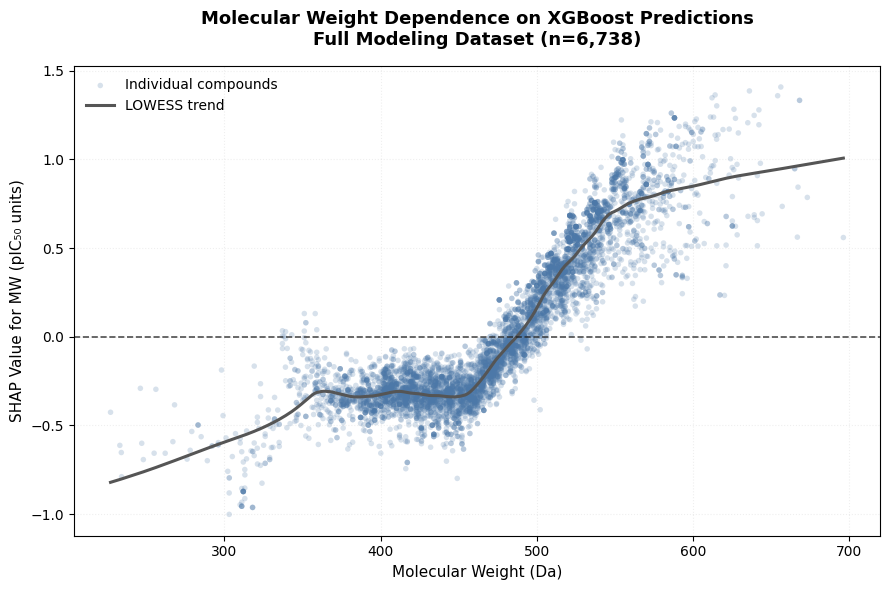

In [8]:
# ============================================================
# 4.1 Molecular Weight (MW) Dependence Analysis
# Full Modeling Dataset (n = 6,738)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess


# ------------------------------------------------------------
# 1. Extract MW values and corresponding SHAP values
# ------------------------------------------------------------

mw_index = X_full.columns.get_loc('MW')

mw_values = X_full['MW'].values

mw_shap = shap_values_full.values[:, mw_index]


# ------------------------------------------------------------
# 2. Create a structured analysis DataFrame
# ------------------------------------------------------------

mw_dependence_df = pd.DataFrame({
    'MW': mw_values,
    'SHAP_MW': mw_shap
})


# ------------------------------------------------------------
# 3. Calculate descriptive MW range
# ------------------------------------------------------------

mw_summary = mw_dependence_df['MW'].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
)

print("--- Molecular Weight Distribution ---")
print(f"Minimum:       {mw_summary['min']:.1f} Da")
print(f"5th percentile:{mw_summary['5%']:8.1f} Da")
print(f"25th percentile:{mw_summary['25%']:7.1f} Da")
print(f"Median:        {mw_summary['50%']:.1f} Da")
print(f"75th percentile:{mw_summary['75%']:7.1f} Da")
print(f"95th percentile:{mw_summary['95%']:7.1f} Da")
print(f"Maximum:       {mw_summary['max']:.1f} Da")


# ------------------------------------------------------------
# 4. Fit LOWESS trend
# ------------------------------------------------------------

# LOWESS provides a locally smoothed representation of the
# model-derived MW-SHAP relationship without assuming linearity.

mw_lowess = lowess(
    endog=mw_dependence_df['SHAP_MW'],
    exog=mw_dependence_df['MW'],
    frac=0.15,
    it=0,
    return_sorted=True
)


# ------------------------------------------------------------
# 5. Plot MW vs. SHAP contribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    mw_dependence_df['MW'],
    mw_dependence_df['SHAP_MW'],
    s=16,
    alpha=0.22,
    color=COLOR_PRIMARY,
    edgecolors='none',
    label='Individual compounds'
)

plt.plot(
    mw_lowess[:, 0],
    mw_lowess[:, 1],
    color=COLOR_TREND,
    linewidth=2.2,
    label='LOWESS trend'
)


# ------------------------------------------------------------
# 6. Add SHAP = 0 reference line
# ------------------------------------------------------------

plt.axhline(
    y=0,
    color=COLOR_ERROR,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8
)


# ------------------------------------------------------------
# 7. Formatting
# ------------------------------------------------------------

plt.xlabel(
    "Molecular Weight (Da)",
    fontsize=11
)

plt.ylabel(
    "SHAP Value for MW (pIC₅₀ units)",
    fontsize=11
)

plt.title(
    "Molecular Weight Dependence on XGBoost Predictions\n"
    "Full Modeling Dataset (n=6,738)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    alpha=0.2,
    linestyle=':'
)

plt.legend(
    frameon=False
)

plt.tight_layout()
plt.show()

#### Molecular Weight Dependence Results

The MW dependence plot reveals a strongly **nonlinear relationship** between molecular weight and its contribution to XGBoost-predicted potency.

At lower molecular weights, MW generally contributes negatively to predicted pIC₅₀. The LOWESS trend remains below zero through much of the lower and intermediate MW range and shows a relatively broad negative region around approximately **375–450 Da**.

A pronounced transition occurs at higher molecular weights. Beginning around the upper 400 Da range, the MW contribution rises rapidly, crossing from negative to positive and continuing upward through approximately **500–550 Da**. Beyond this region, the increase becomes more gradual, suggesting a partial plateau in the positive contribution of MW at higher molecular weights.

This nonlinear pattern helps explain why MW emerged as the dominant descriptor in the XGBoost SHAP analysis. The model does not treat each additional unit of molecular weight as producing a constant change in predicted potency. Instead, the influence of MW varies substantially across molecular-size regions.

The vertical spread of SHAP values among compounds with similar MW also indicates that molecular weight does not act independently. Compounds of comparable size can receive substantially different MW contributions, suggesting that the effect learned for MW may depend on the values of other molecular descriptors.

Because MW is correlated with multiple aspects of molecular structure and composition, this relationship should not be interpreted as evidence that simply increasing molecular weight will increase Nav1.7 inhibitory potency. Rather, the model identifies molecular size as an important component of the physicochemical context associated with potency within the chemical space represented by this dataset.

### 4.2 Fraction Csp³ Dependence Analysis

Fraction Csp³ emerged as the **second most influential descriptor** in the global SHAP analysis, accounting for approximately **17.7% of total mean absolute SHAP importance**. Its importance is particularly notable because its relationship with potency was less prominent in the earlier linear analyses, while both Random Forest and XGBoost identified it as a major source of predictive information.

Fraction Csp³ represents the fraction of carbon atoms in a molecule that are **sp³-hybridized**, providing a broad measure of carbon saturation and three-dimensional molecular character. Higher Fraction Csp³ values generally correspond to molecules containing a greater proportion of saturated, tetrahedral carbon centers relative to sp²- and sp-hybridized carbons.

To examine how this structural property contributes to XGBoost predictions, Fraction Csp³ values are plotted against their corresponding SHAP contributions across the complete **6,738-compound dataset**.

The analysis focuses on whether the effect of Fraction Csp³ is **monotonic or nonlinear**, whether particular ranges shift the model toward higher or lower predicted pIC₅₀, and whether substantial variation exists among compounds with similar Fraction Csp³ values.

The vertical spread of SHAP contributions at comparable Fraction Csp³ values is also of particular interest. A large spread could indicate that the predictive contribution associated with three-dimensional carbon character depends on other molecular properties, motivating subsequent investigation of descriptor interactions.

Because Fraction Csp³ is a coarse structural descriptor rather than a direct measurement of molecular shape or target binding, any favorable or unfavorable ranges identified here are interpreted as **model-derived structure–activity hypotheses rather than evidence that increasing sp³ character alone will alter Nav1.7 inhibitory potency**.

--- Fraction Csp3 Distribution ---
Minimum:        0.000
5th percentile: 0.000
25th percentile: 0.080
Median:         0.190
75th percentile: 0.308
95th percentile: 0.550
Maximum:        1.000


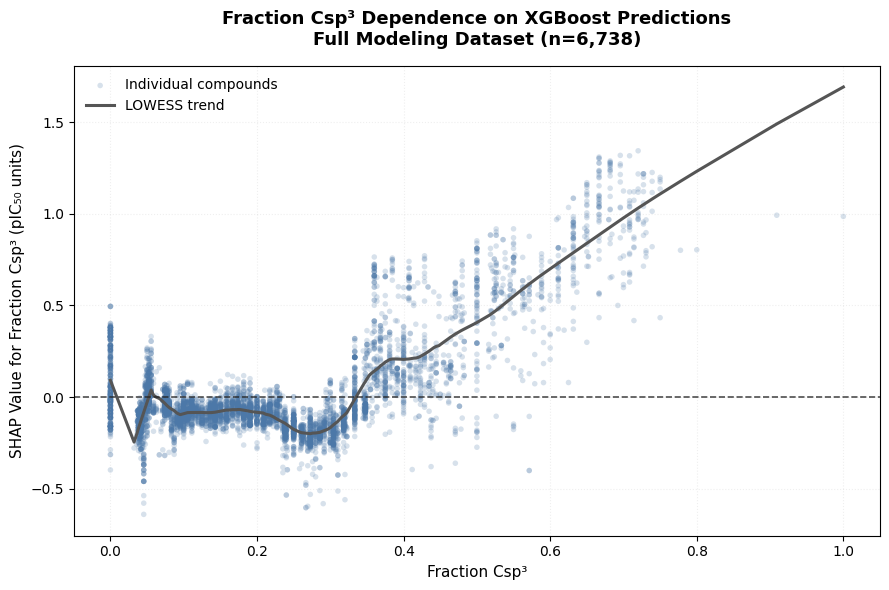

In [9]:
# ============================================================
# 4.2 Fraction Csp3 Dependence Analysis
# Full Modeling Dataset (n = 6,738)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess


# ------------------------------------------------------------
# 1. Extract FractionCSP3 values and corresponding SHAP values
# ------------------------------------------------------------

fcsp3_index = X_full.columns.get_loc('FractionCSP3')

fcsp3_values = X_full['FractionCSP3'].values

fcsp3_shap = shap_values_full.values[:, fcsp3_index]


# ------------------------------------------------------------
# 2. Create structured analysis DataFrame
# ------------------------------------------------------------

fcsp3_dependence_df = pd.DataFrame({
    'FractionCSP3': fcsp3_values,
    'SHAP_FractionCSP3': fcsp3_shap
})


# ------------------------------------------------------------
# 3. Calculate descriptive distribution
# ------------------------------------------------------------

fcsp3_summary = fcsp3_dependence_df[
    'FractionCSP3'
].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
)

print("--- Fraction Csp3 Distribution ---")
print(f"Minimum:        {fcsp3_summary['min']:.3f}")
print(f"5th percentile: {fcsp3_summary['5%']:.3f}")
print(f"25th percentile:{fcsp3_summary['25%']:6.3f}")
print(f"Median:         {fcsp3_summary['50%']:.3f}")
print(f"75th percentile:{fcsp3_summary['75%']:6.3f}")
print(f"95th percentile:{fcsp3_summary['95%']:6.3f}")
print(f"Maximum:        {fcsp3_summary['max']:.3f}")


# ------------------------------------------------------------
# 4. Fit LOWESS trend
# ------------------------------------------------------------

# LOWESS provides a locally smoothed representation of the
# FractionCSP3-SHAP relationship without assuming linearity.

fcsp3_lowess = lowess(
    endog=fcsp3_dependence_df['SHAP_FractionCSP3'],
    exog=fcsp3_dependence_df['FractionCSP3'],
    frac=0.15,
    it=0,
    return_sorted=True
)


# ------------------------------------------------------------
# 5. Plot FractionCSP3 vs. SHAP contribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    fcsp3_dependence_df['FractionCSP3'],
    fcsp3_dependence_df['SHAP_FractionCSP3'],
    s=16,
    alpha=0.22,
    color=COLOR_PRIMARY,
    edgecolors='none',
    label='Individual compounds'
)

plt.plot(
    fcsp3_lowess[:, 0],
    fcsp3_lowess[:, 1],
    color=COLOR_TREND,
    linewidth=2.2,
    label='LOWESS trend'
)


# ------------------------------------------------------------
# 6. Add SHAP = 0 reference line
# ------------------------------------------------------------

plt.axhline(
    y=0,
    color=COLOR_ERROR,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8
)


# ------------------------------------------------------------
# 7. Formatting
# ------------------------------------------------------------

plt.xlabel(
    "Fraction Csp³",
    fontsize=11
)

plt.ylabel(
    "SHAP Value for Fraction Csp³ (pIC₅₀ units)",
    fontsize=11
)

plt.title(
    "Fraction Csp³ Dependence on XGBoost Predictions\n"
    "Full Modeling Dataset (n=6,738)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    alpha=0.2,
    linestyle=':'
)

plt.legend(
    frameon=False
)

plt.tight_layout()
plt.show()

#### Fraction Csp³ Dependence Results

The Fraction Csp³ dependence plot reveals a strongly **nonlinear relationship** between carbon saturation and its contribution to XGBoost-predicted potency.

Across much of the low-to-moderate Fraction Csp³ range, approximately **0.05–0.30**, the SHAP contribution is predominantly negative. The LOWESS trend reaches its most negative region around Fraction Csp³ values in the upper 0.2 range, indicating that compounds in this region tend to receive a modest downward contribution to predicted pIC₅₀ from this descriptor.

A pronounced transition occurs approximately between **0.30 and 0.40**. Within this region, the Fraction Csp³ contribution rises rapidly and changes from predominantly negative to positive. Above approximately **0.4**, increasing Fraction Csp³ is associated with progressively larger positive SHAP contributions, with particularly strong positive effects among compounds possessing high sp³ character.

This nonlinear behavior helps explain why Fraction Csp³ emerged as the second most important descriptor in both the XGBoost SHAP and Random Forest analyses despite its weaker relationship in the earlier linear analysis. A single linear coefficient would be unable to represent the relatively flat or negative behavior across much of the lower range together with the strong positive contribution observed at higher Fraction Csp³ values.

Considerable vertical variation is also present among compounds with similar Fraction Csp³ values, particularly in the intermediate and higher ranges. This indicates that the model does not assign a fixed potency contribution based solely on Fraction Csp³ and suggests that its influence may depend on other molecular properties.

The observed relationship should not be interpreted as evidence that increasing Fraction Csp³ alone will increase Nav1.7 inhibitory potency. Rather, it identifies higher three-dimensional carbon character as a structural feature associated with increasingly favorable model contributions within particular regions of the chemical space represented in this dataset.

### 4.3 LogP Dependence Analysis

LogP emerged as the **third most influential descriptor** in the global SHAP analysis, accounting for approximately **12.9% of total mean absolute SHAP importance**. The SHAP summary plot indicated that very low LogP values were frequently associated with negative contributions to predicted pIC₅₀, while higher values tended to produce less negative or positive contributions.

LogP describes the calculated partitioning of a neutral molecule between nonpolar and aqueous environments and is commonly used as a measure of **molecular lipophilicity**. Lipophilicity can influence several properties relevant to small-molecule activity, including hydrophobic interactions, membrane partitioning, solubility, and the physicochemical environment surrounding ligand–protein interactions.

To characterize the relationship learned by XGBoost in greater detail, LogP values are plotted against their corresponding SHAP contributions across the complete **6,738-compound dataset**.

The analysis examines whether increasing lipophilicity produces a consistently favorable contribution or whether the relationship contains **nonlinear regions, transitions, plateaus, or unfavorable extremes**. Of particular interest is whether the strongly negative contributions associated with low LogP observed in the SHAP summary plot are confined to a specific lipophilicity range and whether increasing LogP eventually reaches a region of diminishing or changing contribution.

Variation in SHAP values among compounds with similar LogP values will also be examined as potential evidence that the model's use of lipophilicity depends on other molecular properties.

Because LogP is correlated with multiple aspects of molecular structure and does not directly represent ligand–channel binding, any favorable LogP range identified by the model is interpreted as a **predictive physicochemical association within the present chemical space rather than an independently optimized lipophilicity requirement for Nav1.7 inhibition**.

--- LogP Distribution ---
Minimum:         -5.520
5th percentile:  2.596
25th percentile: 3.654
Median:          4.405
75th percentile: 5.117
95th percentile: 5.969
Maximum:         8.422


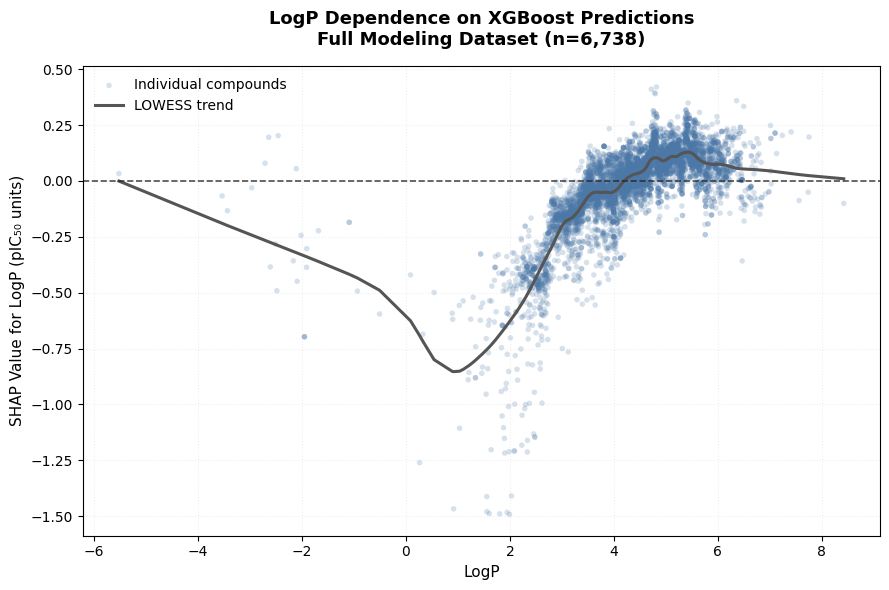

In [10]:
# ============================================================
# 4.3 LogP Dependence Analysis
# Full Modeling Dataset (n = 6,738)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess


# ------------------------------------------------------------
# 1. Extract LogP values and corresponding SHAP values
# ------------------------------------------------------------

logp_index = X_full.columns.get_loc('LogP')

logp_values = X_full['LogP'].values

logp_shap = shap_values_full.values[:, logp_index]


# ------------------------------------------------------------
# 2. Create structured analysis DataFrame
# ------------------------------------------------------------

logp_dependence_df = pd.DataFrame({
    'LogP': logp_values,
    'SHAP_LogP': logp_shap
})


# ------------------------------------------------------------
# 3. Calculate descriptive LogP distribution
# ------------------------------------------------------------

logp_summary = logp_dependence_df['LogP'].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
)

print("--- LogP Distribution ---")
print(f"Minimum:         {logp_summary['min']:.3f}")
print(f"5th percentile:  {logp_summary['5%']:.3f}")
print(f"25th percentile: {logp_summary['25%']:.3f}")
print(f"Median:          {logp_summary['50%']:.3f}")
print(f"75th percentile: {logp_summary['75%']:.3f}")
print(f"95th percentile: {logp_summary['95%']:.3f}")
print(f"Maximum:         {logp_summary['max']:.3f}")


# ------------------------------------------------------------
# 4. Fit LOWESS trend
# ------------------------------------------------------------

# LOWESS reveals the nonlinear relationship between
# lipophilicity and the LogP contribution to predicted pIC50.

logp_lowess = lowess(
    endog=logp_dependence_df['SHAP_LogP'],
    exog=logp_dependence_df['LogP'],
    frac=0.15,
    it=0,
    return_sorted=True
)


# ------------------------------------------------------------
# 5. Plot LogP vs. SHAP contribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    logp_dependence_df['LogP'],
    logp_dependence_df['SHAP_LogP'],
    s=16,
    alpha=0.22,
    color=COLOR_PRIMARY,
    edgecolors='none',
    label='Individual compounds'
)

plt.plot(
    logp_lowess[:, 0],
    logp_lowess[:, 1],
    color=COLOR_TREND,
    linewidth=2.2,
    label='LOWESS trend'
)


# ------------------------------------------------------------
# 6. Add SHAP = 0 reference line
# ------------------------------------------------------------

plt.axhline(
    y=0,
    color=COLOR_ERROR,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8
)


# ------------------------------------------------------------
# 7. Formatting
# ------------------------------------------------------------

plt.xlabel(
    "LogP",
    fontsize=11
)

plt.ylabel(
    "SHAP Value for LogP (pIC₅₀ units)",
    fontsize=11
)

plt.title(
    "LogP Dependence on XGBoost Predictions\n"
    "Full Modeling Dataset (n=6,738)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    alpha=0.2,
    linestyle=':'
)

plt.legend(
    frameon=False
)

plt.tight_layout()
plt.show()

#### LogP Dependence Results

The LogP dependence plot reveals a strongly **nonlinear relationship** between lipophilicity and its contribution to XGBoost-predicted potency.

Low LogP values are associated with strongly negative SHAP contributions. The contribution becomes progressively less unfavorable as LogP increases, with a particularly pronounced rise through approximately the **2–4 LogP range**. This indicates that, within the model, compounds with relatively low lipophilicity tend to receive a substantial downward contribution to predicted pIC₅₀.

The relationship changes at intermediate LogP values. Around the region of approximately **4–6**, LogP contributions are generally near zero or modestly positive, with the LOWESS trend reaching its most favorable region around the upper portion of this range. At still higher LogP values, the trend no longer increases and instead appears to level off or decline modestly toward zero.

This pattern suggests **diminishing predictive benefit from increasing lipophilicity** once an intermediate-to-high LogP range has been reached. The model therefore does not support a simple relationship in which progressively greater lipophilicity continually increases predicted potency.

The distribution of the dataset is important when interpreting the extremes of this relationship. The 5th and 95th percentiles are **LogP = 2.596 and 5.969**, respectively, meaning that approximately 90% of compounds fall within this interval. Trends outside this range are supported by substantially fewer observations and should therefore be interpreted more cautiously.

As with the other descriptor-specific analyses, this relationship represents the contribution assigned to LogP by the fitted XGBoost model rather than an independent causal effect of lipophilicity. Nevertheless, the results suggest that **very low lipophilicity is generally unfavorable within the modeled chemical space, whereas intermediate-to-high lipophilicity is associated with more favorable contributions that eventually show diminishing returns**.

### 4.4 TPSA Dependence Analysis

Topological Polar Surface Area (TPSA) ranked as the **fourth most influential descriptor** in the global SHAP analysis, accounting for approximately **10.7% of total mean absolute SHAP importance**. Unlike MW, Fraction Csp³, and LogP, the SHAP summary plot showed substantial overlap between low and high TPSA values on both the positive and negative sides of the SHAP distribution, suggesting a potentially more complex relationship with predicted potency.

TPSA provides an estimate of the molecular surface area associated primarily with **polar heteroatoms and their attached hydrogens**. It is widely used as a descriptor of molecular polarity and is related to properties such as hydrogen-bonding capacity, solvation, membrane permeability, and the balance between polar and nonpolar molecular character.

To examine how XGBoost uses this descriptor, TPSA values are plotted against their corresponding SHAP contributions across the complete **6,738-compound dataset**.

The analysis investigates whether TPSA exhibits a simple directional relationship or instead contains **favorable and unfavorable regions, nonlinear transitions, or intermediate ranges associated with different model contributions**. Particular attention is given to whether both very low and very high polarity produce different effects from intermediate TPSA values.

Variation in SHAP contributions among compounds with similar TPSA values will also be examined. Substantial vertical dispersion would suggest that the influence assigned to molecular polarity depends on other physicochemical or structural properties rather than TPSA alone.

Because TPSA is a broad descriptor of molecular polarity and does not directly represent specific ligand–protein interactions, any favorable or unfavorable TPSA ranges identified by the model are interpreted as **model-derived physicochemical associations within the present chemical space rather than independently optimized polarity requirements for Nav1.7 inhibition**.

--- TPSA Distribution ---
Minimum:         15.27 Å²
5th percentile:  58.47 Å²
25th percentile: 78.76 Å²
Median:          94.07 Å²
75th percentile: 109.86 Å²
95th percentile: 130.49 Å²
Maximum:         215.23 Å²


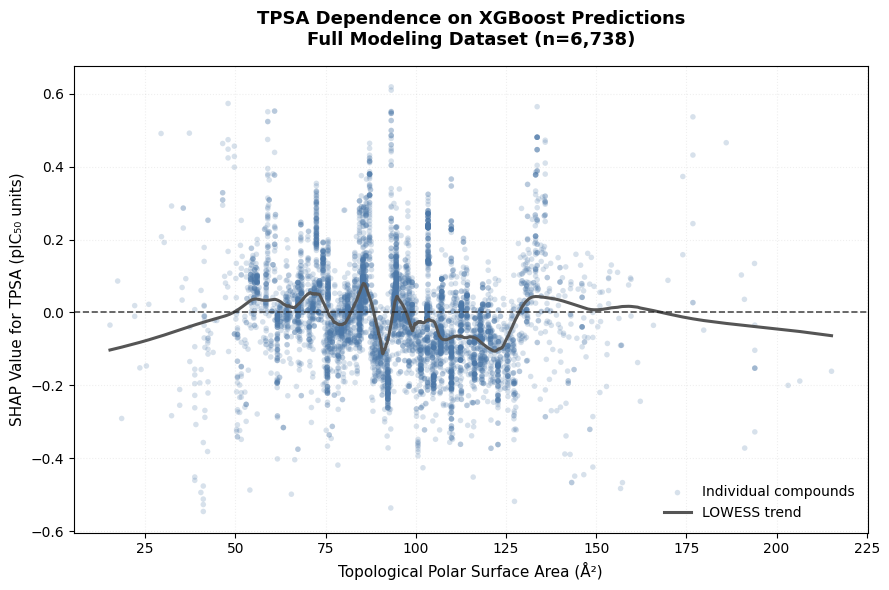

In [11]:
# ============================================================
# 4.4 TPSA Dependence Analysis
# Full Modeling Dataset (n = 6,738)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess


# ------------------------------------------------------------
# 1. Extract TPSA values and corresponding SHAP values
# ------------------------------------------------------------

tpsa_index = X_full.columns.get_loc('TPSA')

tpsa_values = X_full['TPSA'].values

tpsa_shap = shap_values_full.values[:, tpsa_index]


# ------------------------------------------------------------
# 2. Create structured analysis DataFrame
# ------------------------------------------------------------

tpsa_dependence_df = pd.DataFrame({
    'TPSA': tpsa_values,
    'SHAP_TPSA': tpsa_shap
})


# ------------------------------------------------------------
# 3. Calculate descriptive TPSA distribution
# ------------------------------------------------------------

tpsa_summary = tpsa_dependence_df['TPSA'].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
)

print("--- TPSA Distribution ---")
print(f"Minimum:         {tpsa_summary['min']:.2f} Å²")
print(f"5th percentile:  {tpsa_summary['5%']:.2f} Å²")
print(f"25th percentile: {tpsa_summary['25%']:.2f} Å²")
print(f"Median:          {tpsa_summary['50%']:.2f} Å²")
print(f"75th percentile: {tpsa_summary['75%']:.2f} Å²")
print(f"95th percentile: {tpsa_summary['95%']:.2f} Å²")
print(f"Maximum:         {tpsa_summary['max']:.2f} Å²")


# ------------------------------------------------------------
# 4. Fit LOWESS trend
# ------------------------------------------------------------

# LOWESS provides a locally smoothed representation of the
# TPSA-SHAP relationship without assuming linearity.

tpsa_lowess = lowess(
    endog=tpsa_dependence_df['SHAP_TPSA'],
    exog=tpsa_dependence_df['TPSA'],
    frac=0.15,
    it=0,
    return_sorted=True
)


# ------------------------------------------------------------
# 5. Plot TPSA vs. SHAP contribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    tpsa_dependence_df['TPSA'],
    tpsa_dependence_df['SHAP_TPSA'],
    s=16,
    alpha=0.22,
    color=COLOR_PRIMARY,
    edgecolors='none',
    label='Individual compounds'
)

plt.plot(
    tpsa_lowess[:, 0],
    tpsa_lowess[:, 1],
    color=COLOR_TREND,
    linewidth=2.2,
    label='LOWESS trend'
)


# ------------------------------------------------------------
# 6. Add SHAP = 0 reference line
# ------------------------------------------------------------

plt.axhline(
    y=0,
    color=COLOR_ERROR,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8
)


# ------------------------------------------------------------
# 7. Formatting
# ------------------------------------------------------------

plt.xlabel(
    "Topological Polar Surface Area (Å²)",
    fontsize=11
)

plt.ylabel(
    "SHAP Value for TPSA (pIC₅₀ units)",
    fontsize=11
)

plt.title(
    "TPSA Dependence on XGBoost Predictions\n"
    "Full Modeling Dataset (n=6,738)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    alpha=0.2,
    linestyle=':'
)

plt.legend(
    frameon=False
)

plt.tight_layout()
plt.show()

#### TPSA Dependence Results

The TPSA dependence analysis reveals a more complex and substantially less directional relationship than those observed for MW, Fraction Csp³, and LogP.

Across most of the densely populated TPSA range, the LOWESS trend remains relatively close to zero, indicating that TPSA generally makes a modest average contribution to predicted pIC₅₀. Rather than showing a continuous increase or decrease, the relationship contains several localized positive and negative regions.

Within the central portion of the dataset, TPSA values around approximately **100–125 Å²** tend to produce modestly negative SHAP contributions. The trend subsequently rises around **130–145 Å²**, where TPSA contributions become slightly positive before returning toward approximately neutral values at higher TPSA.

Considerable vertical dispersion is present throughout the plot. Compounds with similar TPSA values can receive both positive and negative SHAP contributions, in some cases differing by several tenths of a pIC₅₀ unit. This heterogeneity suggests that the influence assigned to TPSA depends substantially on the broader physicochemical context of each molecule rather than on polarity alone.

The distribution of the dataset should also be considered when interpreting the outer regions. Approximately 90% of compounds have TPSA values between **58.47 and 130.49 Å²**, whereas observations at very low and particularly very high TPSA are comparatively sparse. Trends in these extreme regions therefore provide weaker evidence than patterns within the central descriptor range.

Overall, the model does not identify a simple relationship in which increasing or decreasing TPSA consistently favors predicted Nav1.7 potency. Instead, TPSA appears to function as a **context-dependent molecular property**, consistent with its mixed high- and low-value distribution observed in the global SHAP summary plot.

### 4.5 Rotatable Bonds Dependence Analysis

Rotatable Bonds ranked as the **fifth most influential descriptor** in the global SHAP analysis, accounting for approximately **8.2% of total mean absolute SHAP importance**. The SHAP summary plot indicated that most Rotatable Bonds contributions were concentrated relatively close to zero, while a subset of compounds showed substantially negative contributions.

The number of rotatable bonds provides a simple measure of **molecular flexibility**. Molecules with more rotatable bonds generally possess greater conformational freedom, whereas molecules with fewer rotatable bonds tend to be more conformationally constrained. Molecular flexibility can influence ligand binding by affecting accessible conformations and the conformational cost associated with adopting a binding-compatible geometry.

To examine how molecular flexibility contributes to XGBoost predictions, Rotatable Bonds values are plotted against their corresponding SHAP contributions across the complete **6,738-compound dataset**.

Because Rotatable Bonds is a **discrete count descriptor**, compounds occur at integer values rather than continuously across the x-axis. The analysis therefore focuses on whether increasing flexibility is associated with systematic changes in SHAP contribution and whether particular ranges of rotatable-bond counts produce predominantly favorable, unfavorable, or neutral effects.

Particular attention is given to whether the model identifies **diminishing contributions or penalties at higher levels of molecular flexibility**, as suggested by the negative tail observed in the global SHAP summary plot. Variation in SHAP contributions among compounds with the same number of rotatable bonds will also provide information about the extent to which flexibility acts in combination with other molecular properties.

Any relationship identified here represents the role assigned to molecular flexibility within the fitted XGBoost model. It should therefore be interpreted as a **model-derived structure–activity association rather than evidence that changing the number of rotatable bonds alone will alter Nav1.7 inhibitory potency**.

--- Rotatable Bonds Distribution ---
Minimum:         1
5th percentile:  3
25th percentile: 5
Median:          6
75th percentile: 7
95th percentile: 8
Maximum:         22

--- Compounds by Rotatable Bond Count ---


,RotatableBonds,CompoundCount
0,1.0,11
1,2.0,57
2,3.0,310
3,4.0,740
4,5.0,990
5,6.0,2421
6,7.0,1380
7,8.0,530
8,9.0,217
9,10.0,57


/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


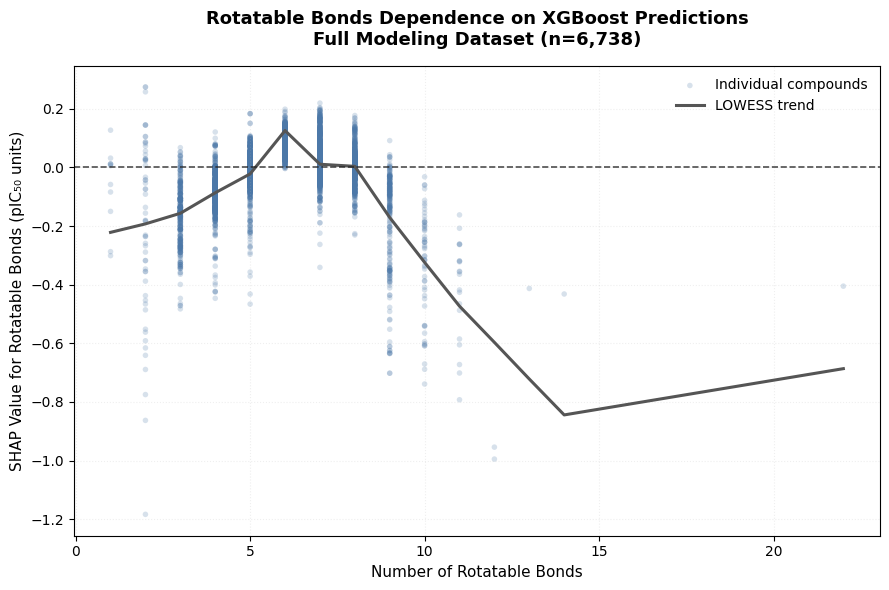

In [12]:
# ============================================================
# 4.5 Rotatable Bonds Dependence Analysis
# Full Modeling Dataset (n = 6,738)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess


# ------------------------------------------------------------
# 1. Extract Rotatable Bonds values and corresponding SHAP values
# ------------------------------------------------------------

rotb_index = X_full.columns.get_loc('RotatableBonds')

rotb_values = X_full['RotatableBonds'].values

rotb_shap = shap_values_full.values[:, rotb_index]


# ------------------------------------------------------------
# 2. Create structured analysis DataFrame
# ------------------------------------------------------------

rotb_dependence_df = pd.DataFrame({
    'RotatableBonds': rotb_values,
    'SHAP_RotatableBonds': rotb_shap
})


# ------------------------------------------------------------
# 3. Calculate descriptive distribution
# ------------------------------------------------------------

rotb_summary = rotb_dependence_df[
    'RotatableBonds'
].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
)

print("--- Rotatable Bonds Distribution ---")
print(f"Minimum:         {rotb_summary['min']:.0f}")
print(f"5th percentile:  {rotb_summary['5%']:.0f}")
print(f"25th percentile: {rotb_summary['25%']:.0f}")
print(f"Median:          {rotb_summary['50%']:.0f}")
print(f"75th percentile: {rotb_summary['75%']:.0f}")
print(f"95th percentile: {rotb_summary['95%']:.0f}")
print(f"Maximum:         {rotb_summary['max']:.0f}")


# ------------------------------------------------------------
# 4. Count compounds at each Rotatable Bonds value
# ------------------------------------------------------------

rotb_counts = (
    rotb_dependence_df['RotatableBonds']
    .value_counts()
    .sort_index()
    .rename_axis('RotatableBonds')
    .reset_index(name='CompoundCount')
)

print("\n--- Compounds by Rotatable Bond Count ---")
display(rotb_counts)


# ------------------------------------------------------------
# 5. Fit LOWESS trend
# ------------------------------------------------------------

# RotatableBonds is discrete, but LOWESS is retained here
# for consistency with Sections 4.1–4.4 and to visualize
# the overall model-derived trend.

rotb_lowess = lowess(
    endog=rotb_dependence_df['SHAP_RotatableBonds'],
    exog=rotb_dependence_df['RotatableBonds'],
    frac=0.20,
    it=0,
    return_sorted=True
)


# ------------------------------------------------------------
# 6. Plot Rotatable Bonds vs. SHAP contribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    rotb_dependence_df['RotatableBonds'],
    rotb_dependence_df['SHAP_RotatableBonds'],
    s=16,
    alpha=0.22,
    color=COLOR_PRIMARY,
    edgecolors='none',
    label='Individual compounds'
)

plt.plot(
    rotb_lowess[:, 0],
    rotb_lowess[:, 1],
    color=COLOR_TREND,
    linewidth=2.2,
    label='LOWESS trend'
)


# ------------------------------------------------------------
# 7. Add SHAP = 0 reference line
# ------------------------------------------------------------

plt.axhline(
    y=0,
    color=COLOR_ERROR,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8
)


# ------------------------------------------------------------
# 8. Formatting
# ------------------------------------------------------------

plt.xlabel(
    "Number of Rotatable Bonds",
    fontsize=11
)

plt.ylabel(
    "SHAP Value for Rotatable Bonds (pIC₅₀ units)",
    fontsize=11
)

plt.title(
    "Rotatable Bonds Dependence on XGBoost Predictions\n"
    "Full Modeling Dataset (n=6,738)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    alpha=0.2,
    linestyle=':'
)

plt.legend(
    frameon=False
)

plt.tight_layout()
plt.show()

#### Rotatable Bonds Dependence Results

The Rotatable Bonds dependence analysis reveals a nonlinear relationship between molecular flexibility and its contribution to XGBoost-predicted potency.

Within the densely populated region of the dataset, the contribution associated with Rotatable Bonds generally becomes less negative as the number of rotatable bonds increases from approximately **3 to 6**. The LOWESS trend reaches its most favorable region around **6 rotatable bonds**, where the average contribution becomes modestly positive.

Beyond this region, the relationship changes direction. Contributions return toward approximately neutral values around **7–8 rotatable bonds** and become increasingly negative around **9–10 rotatable bonds**. This pattern suggests that greater molecular flexibility beyond the central range is associated with an increasingly unfavorable contribution to predicted pIC₅₀ within the XGBoost model.

The distribution of compounds is particularly important for interpreting this descriptor. Approximately **90% of the dataset contains 3–8 rotatable bonds**, and the median is 6. In contrast, only 25 compounds contain 11 or more rotatable bonds. Consequently, the apparent LOWESS behavior at very high rotatable-bond counts is supported by sparse observations and should not be interpreted as evidence of a reliable trend or recovery in SHAP contribution.

Substantial vertical variation is also present among compounds with identical rotatable-bond counts. This indicates that molecular flexibility alone does not determine its model contribution and that its effect likely depends on other structural and physicochemical characteristics.

Overall, the best-supported pattern suggests that **moderate molecular flexibility is relatively favorable, whereas increasing flexibility beyond approximately 7–8 rotatable bonds becomes progressively less favorable within the densely sampled chemical space**. This represents a model-derived association rather than an independently optimized flexibility requirement for Nav1.7 inhibition.

### 4.6 Hydrogen-Bond Donor (HBD) Dependence Analysis

Hydrogen-Bond Donors (HBD) ranked as the **sixth most influential descriptor** in the global SHAP analysis, accounting for approximately **7.2% of total mean absolute SHAP importance**. Although its overall importance was relatively modest, the SHAP summary plot showed an asymmetric distribution in which low HBD values were associated with some substantially negative contributions, while higher values more frequently appeared on the positive side of the SHAP distribution.

HBD represents the number of functional groups capable of **donating a hydrogen atom in a hydrogen-bonding interaction**, typically involving heteroatoms such as nitrogen or oxygen. Hydrogen-bond donation can influence ligand–protein interactions as well as broader physicochemical properties including polarity, solvation, and membrane permeability.

To examine how hydrogen-bond donor count contributes to XGBoost predictions, HBD values are plotted against their corresponding SHAP contributions across the complete **6,738-compound dataset**.

Because HBD is a **discrete count descriptor**, the analysis focuses on differences among individual donor counts rather than assuming a continuous relationship. Of particular interest is whether compounds with no hydrogen-bond donors receive systematically different contributions from compounds containing one or more donors, and whether additional donors continue to produce increasingly favorable contributions or show diminishing effects.

The distribution of compounds at each HBD count is also considered when interpreting the results, since uncommon high-HBD values may represent sparsely sampled regions of chemical space.

Variation in SHAP contributions among compounds sharing the same HBD count will provide additional information about whether hydrogen-bond donation acts consistently or depends strongly on other molecular properties.

Any observed relationship represents the contribution assigned to HBD by the fitted XGBoost model and is therefore interpreted as a **model-derived structure–activity association rather than evidence that adding or removing a hydrogen-bond donor alone will alter Nav1.7 inhibitory potency**.

--- Hydrogen-Bond Donor (HBD) Distribution ---
Minimum:         0
5th percentile:  0
25th percentile: 1
Median:          1
75th percentile: 2
95th percentile: 3
Maximum:         9

--- Compounds by HBD Count ---


,HBD,CompoundCount,Percentage (%)
0,0,601,8.9
1,1,"3,916",58.1
2,2,"1,731",25.7
3,3,433,6.4
4,4,33,0.5
5,7,2,0.0
6,8,14,0.2
7,9,8,0.1



--- Mean SHAP Contribution by HBD Count ---


,HBD,CompoundCount,MeanSHAP,MedianSHAP
0,0,601,-0.2899,-0.2536
1,1,"3,916",-0.0149,-0.0135
2,2,"1,731",0.0798,0.0638
3,3,433,0.1586,0.1608
4,4,33,0.1466,0.1469
5,7,2,0.0633,0.0633
6,8,14,0.1934,0.2122
7,9,8,0.6375,0.6363


/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


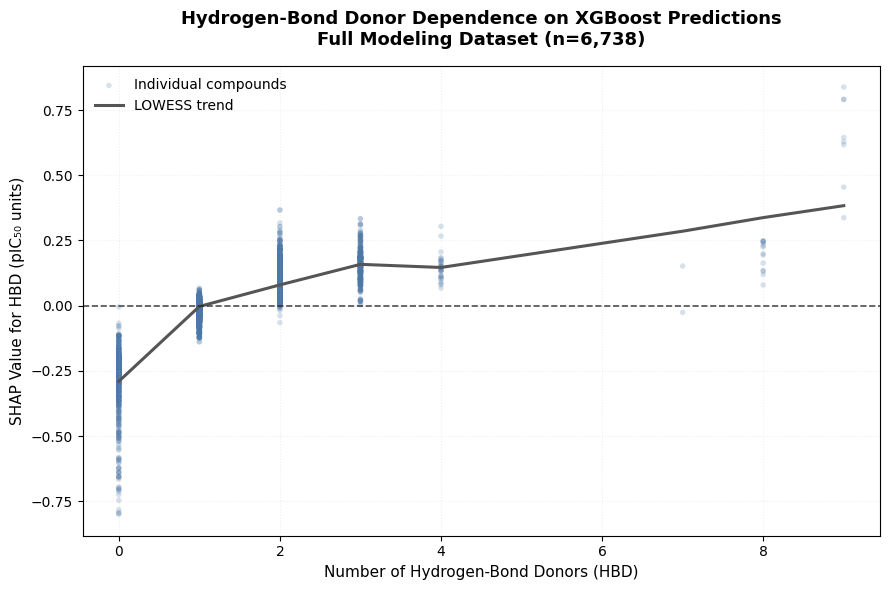

In [13]:
# ============================================================
# 4.6 Hydrogen-Bond Donor (HBD) Dependence Analysis
# Full Modeling Dataset (n = 6,738)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess


# ------------------------------------------------------------
# 1. Extract HBD values and corresponding SHAP values
# ------------------------------------------------------------

hbd_index = X_full.columns.get_loc('HBD')

hbd_values = X_full['HBD'].values

hbd_shap = shap_values_full.values[:, hbd_index]


# ------------------------------------------------------------
# 2. Create structured analysis DataFrame
# ------------------------------------------------------------

hbd_dependence_df = pd.DataFrame({
    'HBD': hbd_values,
    'SHAP_HBD': hbd_shap
})


# ------------------------------------------------------------
# 3. Calculate descriptive HBD distribution
# ------------------------------------------------------------

hbd_summary = hbd_dependence_df['HBD'].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
)

print("--- Hydrogen-Bond Donor (HBD) Distribution ---")
print(f"Minimum:         {hbd_summary['min']:.0f}")
print(f"5th percentile:  {hbd_summary['5%']:.0f}")
print(f"25th percentile: {hbd_summary['25%']:.0f}")
print(f"Median:          {hbd_summary['50%']:.0f}")
print(f"75th percentile: {hbd_summary['75%']:.0f}")
print(f"95th percentile: {hbd_summary['95%']:.0f}")
print(f"Maximum:         {hbd_summary['max']:.0f}")


# ------------------------------------------------------------
# 4. Count compounds at each HBD value
# ------------------------------------------------------------

hbd_counts = (
    hbd_dependence_df['HBD']
    .value_counts()
    .sort_index()
    .rename_axis('HBD')
    .reset_index(name='CompoundCount')
)

hbd_counts['Percentage (%)'] = (
    hbd_counts['CompoundCount']
    / len(hbd_dependence_df)
    * 100
)

print("\n--- Compounds by HBD Count ---")

display(
    hbd_counts.style.format({
        'HBD': '{:.0f}',
        'CompoundCount': '{:,}',
        'Percentage (%)': '{:.1f}'
    })
)


# ------------------------------------------------------------
# 5. Calculate mean SHAP contribution at each HBD count
# ------------------------------------------------------------

# Because HBD is discrete, the mean SHAP value for each exact
# donor count provides a useful complement to the LOWESS curve.

hbd_grouped = (
    hbd_dependence_df
    .groupby('HBD')
    .agg(
        CompoundCount=('SHAP_HBD', 'size'),
        MeanSHAP=('SHAP_HBD', 'mean'),
        MedianSHAP=('SHAP_HBD', 'median')
    )
    .reset_index()
)

print("\n--- Mean SHAP Contribution by HBD Count ---")

display(
    hbd_grouped.style.format({
        'HBD': '{:.0f}',
        'CompoundCount': '{:,}',
        'MeanSHAP': '{:.4f}',
        'MedianSHAP': '{:.4f}'
    })
)


# ------------------------------------------------------------
# 6. Fit LOWESS trend
# ------------------------------------------------------------

# HBD is discrete, so LOWESS is used only as a visual guide
# to the overall model-derived pattern.

hbd_lowess = lowess(
    endog=hbd_dependence_df['SHAP_HBD'],
    exog=hbd_dependence_df['HBD'],
    frac=0.30,
    it=0,
    return_sorted=True
)


# ------------------------------------------------------------
# 7. Plot HBD vs. SHAP contribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    hbd_dependence_df['HBD'],
    hbd_dependence_df['SHAP_HBD'],
    s=16,
    alpha=0.22,
    color=COLOR_PRIMARY,
    edgecolors='none',
    label='Individual compounds'
)

plt.plot(
    hbd_lowess[:, 0],
    hbd_lowess[:, 1],
    color=COLOR_TREND,
    linewidth=2.2,
    label='LOWESS trend'
)


# ------------------------------------------------------------
# 8. Add SHAP = 0 reference line
# ------------------------------------------------------------

plt.axhline(
    y=0,
    color=COLOR_ERROR,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8
)


# ------------------------------------------------------------
# 9. Formatting
# ------------------------------------------------------------

plt.xlabel(
    "Number of Hydrogen-Bond Donors (HBD)",
    fontsize=11
)

plt.ylabel(
    "SHAP Value for HBD (pIC₅₀ units)",
    fontsize=11
)

plt.title(
    "Hydrogen-Bond Donor Dependence on XGBoost Predictions\n"
    "Full Modeling Dataset (n=6,738)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    alpha=0.2,
    linestyle=':'
)

plt.legend(
    frameon=False
)

plt.tight_layout()
plt.show()

#### Hydrogen-Bond Donor Dependence Results

The HBD dependence analysis reveals a clear relationship between hydrogen-bond donor count and its contribution to XGBoost-predicted potency within the well-sampled region of the dataset.

Compounds containing **no hydrogen-bond donors** show a distinctly unfavorable model contribution. Among the 601 compounds with HBD = 0, the mean SHAP contribution is **−0.290 pIC₅₀ units**, substantially lower than that observed for any of the commonly represented donor-containing groups.

Introducing one hydrogen-bond donor is associated with a pronounced shift toward neutrality. HBD = 1, which represents **58.1% of the dataset**, has a mean SHAP contribution of approximately **−0.015 pIC₅₀ units**. Contributions become increasingly positive at HBD = 2 and HBD = 3, with mean SHAP values of approximately **+0.080** and **+0.159 pIC₅₀ units**, respectively.

The best-supported model-derived pattern is therefore:

**HBD = 0: unfavorable → HBD = 1: approximately neutral → HBD = 2–3: increasingly favorable**

Interpretation beyond this range requires substantial caution. Approximately **99.1% of compounds contain three or fewer hydrogen-bond donors**, while only 57 compounds have HBD ≥ 4. In particular, the large positive contribution observed for HBD = 9 is based on only eight compounds and should not be interpreted as evidence that very high hydrogen-bond donor counts are generally favorable.

The substantial spread of SHAP values within individual HBD groups also indicates that donor count does not act independently. Nevertheless, the pronounced difference between HBD = 0 and the well-populated HBD = 1–3 groups suggests that the **presence of hydrogen-bond donor functionality is an important model-derived structural distinction**, even though HBD contributes less to overall model importance than MW, Fraction Csp³, LogP, and TPSA.

These results do not establish that adding hydrogen-bond donors will directly increase Nav1.7 inhibitory potency. HBD count is correlated with functional-group identity, molecular polarity, and other structural characteristics, so the observed relationship should be interpreted within the broader physicochemical context of the molecules represented in this dataset.

### 4.7 Ring Count Dependence Analysis

Ring Count ranked as the **seventh and least influential descriptor** in the global SHAP analysis, accounting for approximately **6.2% of total mean absolute SHAP importance**. Although its overall contribution to the XGBoost model was smaller than that of the other descriptors, the SHAP summary plot suggested that ring count may still produce systematic positive or negative contributions within particular regions of chemical space.

Ring Count provides a simple measure of the number of **cyclic structural elements** within a molecule. Increasing ring content can influence molecular rigidity, shape, conformational freedom, aromatic character, and overall structural complexity. However, Ring Count does not distinguish between aromatic and nonaromatic rings, ring sizes, fused systems, or heterocycles, so molecules with the same ring count can possess substantially different chemical structures.

To examine how cyclic structural content contributes to XGBoost predictions, Ring Count values are plotted against their corresponding SHAP contributions across the complete **6,738-compound dataset**.

Because Ring Count is a **discrete count descriptor**, the analysis focuses on differences among individual ring counts rather than assuming a continuous relationship. Of particular interest is whether compounds with relatively few rings receive systematically different contributions from molecules with intermediate or higher ring counts, and whether the model identifies a region in which additional rings cease to provide favorable contributions.

The number of compounds at each ring count and the mean and median SHAP contributions within each group are also examined. This is especially important for high ring counts, which may represent sparsely populated regions of the dataset and therefore provide weaker evidence for general structure–activity trends.

Variation in SHAP contributions among compounds sharing the same ring count will also indicate how strongly the influence of cyclic structure depends on other molecular characteristics.

Because Ring Count captures only the **quantity of rings rather than their chemical identity or topology**, any observed relationship is interpreted as a model-derived structural association. More detailed conclusions about aromaticity, heterocycles, fused-ring systems, or specific ring scaffolds would require molecular features beyond the seven descriptors used in the present QSAR model.

--- Ring Count Distribution ---
Minimum:         1
5th percentile:  3
25th percentile: 4
Median:          4
75th percentile: 5
95th percentile: 5
Maximum:         8

--- Compounds by Ring Count ---


,RingCount,CompoundCount,Percentage (%)
0,1,6,0.1
1,2,126,1.9
2,3,"1,046",15.5
3,4,"3,148",46.7
4,5,"2,167",32.2
5,6,186,2.8
6,7,48,0.7
7,8,11,0.2



--- Mean SHAP Contribution by Ring Count ---


,RingCount,CompoundCount,MeanSHAP,MedianSHAP
0,1,6,-0.2511,-0.2639
1,2,126,-0.0750,-0.0582
2,3,"1,046",0.0689,0.0624
3,4,"3,148",-0.0663,-0.0597
4,5,"2,167",0.0203,0.0234
5,6,186,0.0479,0.0466
6,7,48,0.0351,0.0314
7,8,11,0.0074,0.0054


/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


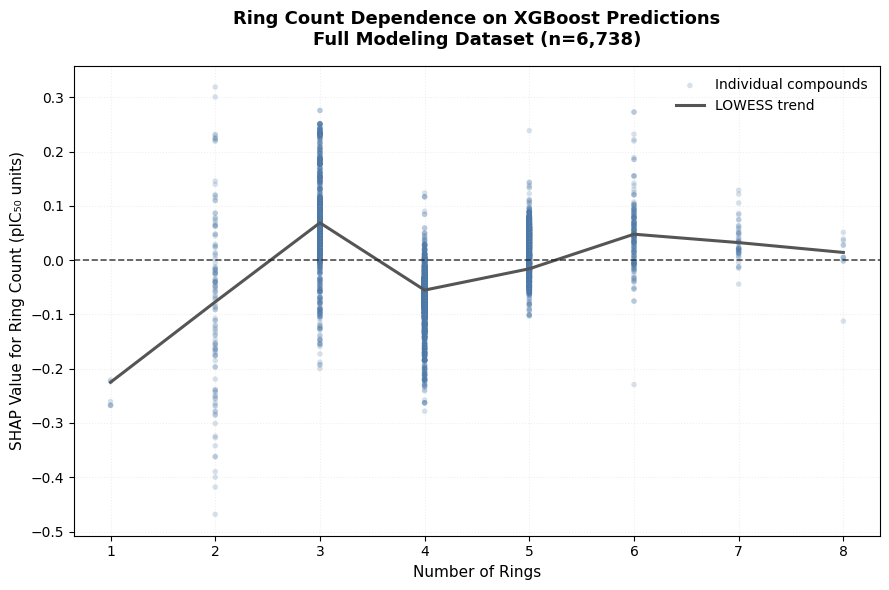

In [14]:
# ============================================================
# 4.7 Ring Count Dependence Analysis
# Full Modeling Dataset (n = 6,738)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess


# ------------------------------------------------------------
# 1. Extract Ring Count values and corresponding SHAP values
# ------------------------------------------------------------

ring_index = X_full.columns.get_loc('RingCount')

ring_values = X_full['RingCount'].values
ring_shap = shap_values_full.values[:, ring_index]


# ------------------------------------------------------------
# 2. Create structured analysis DataFrame
# ------------------------------------------------------------

ring_dependence_df = pd.DataFrame({
    'RingCount': ring_values,
    'SHAP_RingCount': ring_shap
})


# ------------------------------------------------------------
# 3. Calculate descriptive Ring Count distribution
# ------------------------------------------------------------

ring_summary = ring_dependence_df['RingCount'].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
)

print("--- Ring Count Distribution ---")
print(f"Minimum:         {ring_summary['min']:.0f}")
print(f"5th percentile:  {ring_summary['5%']:.0f}")
print(f"25th percentile: {ring_summary['25%']:.0f}")
print(f"Median:          {ring_summary['50%']:.0f}")
print(f"75th percentile: {ring_summary['75%']:.0f}")
print(f"95th percentile: {ring_summary['95%']:.0f}")
print(f"Maximum:         {ring_summary['max']:.0f}")


# ------------------------------------------------------------
# 4. Count compounds at each Ring Count
# ------------------------------------------------------------

ring_counts = (
    ring_dependence_df['RingCount']
    .value_counts()
    .sort_index()
    .rename_axis('RingCount')
    .reset_index(name='CompoundCount')
)

ring_counts['Percentage (%)'] = (
    ring_counts['CompoundCount']
    / len(ring_dependence_df)
    * 100
)

print("\n--- Compounds by Ring Count ---")

display(
    ring_counts.style.format({
        'RingCount': '{:.0f}',
        'CompoundCount': '{:,}',
        'Percentage (%)': '{:.1f}'
    })
)


# ------------------------------------------------------------
# 5. Calculate mean and median SHAP by Ring Count
# ------------------------------------------------------------

ring_grouped = (
    ring_dependence_df
    .groupby('RingCount')
    .agg(
        CompoundCount=('SHAP_RingCount', 'size'),
        MeanSHAP=('SHAP_RingCount', 'mean'),
        MedianSHAP=('SHAP_RingCount', 'median')
    )
    .reset_index()
)

print("\n--- Mean SHAP Contribution by Ring Count ---")

display(
    ring_grouped.style.format({
        'RingCount': '{:.0f}',
        'CompoundCount': '{:,}',
        'MeanSHAP': '{:.4f}',
        'MedianSHAP': '{:.4f}'
    })
)


# ------------------------------------------------------------
# 6. Fit LOWESS trend
# ------------------------------------------------------------

# RingCount is discrete, so LOWESS is used only as a visual
# guide to the overall model-derived relationship.

ring_lowess = lowess(
    endog=ring_dependence_df['SHAP_RingCount'],
    exog=ring_dependence_df['RingCount'],
    frac=0.30,
    it=0,
    return_sorted=True
)


# ------------------------------------------------------------
# 7. Plot Ring Count vs. SHAP contribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    ring_dependence_df['RingCount'],
    ring_dependence_df['SHAP_RingCount'],
    s=16,
    alpha=0.22,
    color=COLOR_PRIMARY,
    edgecolors='none',
    label='Individual compounds'
)

plt.plot(
    ring_lowess[:, 0],
    ring_lowess[:, 1],
    color=COLOR_TREND,
    linewidth=2.2,
    label='LOWESS trend'
)


# ------------------------------------------------------------
# 8. Add SHAP = 0 reference line
# ------------------------------------------------------------

plt.axhline(
    y=0,
    color=COLOR_ERROR,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8
)


# ------------------------------------------------------------
# 9. Use integer x-axis ticks
# ------------------------------------------------------------

ring_min = int(ring_dependence_df['RingCount'].min())
ring_max = int(ring_dependence_df['RingCount'].max())

plt.xticks(
    range(ring_min, ring_max + 1)
)


# ------------------------------------------------------------
# 10. Formatting
# ------------------------------------------------------------

plt.xlabel(
    "Number of Rings",
    fontsize=11
)

plt.ylabel(
    "SHAP Value for Ring Count (pIC₅₀ units)",
    fontsize=11
)

plt.title(
    "Ring Count Dependence on XGBoost Predictions\n"
    "Full Modeling Dataset (n=6,738)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    alpha=0.2,
    linestyle=':'
)

plt.legend(
    frameon=False
)

plt.tight_layout()
plt.show()

#### Ring Count Dependence Results

The Ring Count dependence analysis reveals a **non-monotonic and context-dependent relationship** between the number of rings and its contribution to XGBoost-predicted potency.

The most reliable interpretation comes from compounds containing **3–5 rings**, which account for approximately **94.4% of the dataset**. Within this well-sampled region, compounds with three rings show a modestly positive mean SHAP contribution of approximately **+0.069 pIC₅₀ units**, whereas four-ring compounds show a modestly negative mean contribution of approximately **−0.066 pIC₅₀ units**. At five rings, the mean contribution returns to slightly positive at approximately **+0.020 pIC₅₀ units**.

This alternating behavior demonstrates that Ring Count does not produce a simple relationship in which progressively increasing or decreasing the number of rings consistently favors predicted potency. Instead, different ring-count regions receive relatively small positive or negative contributions from the model.

Compounds with six rings also show a modest positive mean contribution of approximately **+0.048 pIC₅₀ units**, but this group represents only 2.8% of the dataset. Interpretation becomes increasingly uncertain at still higher or lower ring counts. In particular, the strongly negative contributions associated with one ring are based on only six compounds, while seven- and eight-ring molecules together account for less than 1% of the dataset.

Substantial SHAP variation is also present among compounds sharing the same ring count. This is consistent with the limited structural information contained in this descriptor: molecules with identical ring counts may differ substantially in aromaticity, heterocycle composition, ring size, fusion pattern, substitution, and three-dimensional architecture.

Overall, Ring Count appears to provide **modest, nonlinear, and strongly context-dependent predictive information** rather than defining a clear favorable number of rings for Nav1.7 inhibition. This behavior is consistent with its position as the least influential of the seven descriptors in the global SHAP analysis.

More detailed interpretation of cyclic structural effects would require molecular representations capable of distinguishing specific ring types, scaffolds, and substitution patterns rather than Ring Count alone.

## 5. Descriptor Interaction Analysis

The descriptor-specific SHAP dependence analyses demonstrated that the XGBoost model learned substantial nonlinear relationships between molecular properties and predicted Nav1.7 inhibitory potency. Molecular Weight (MW), Fraction Csp³, and LogP showed particularly strong systematic effects, while considerable variation in SHAP contributions remained among compounds with similar descriptor values.

This variation suggests that the contribution of one molecular property may depend on the values of other descriptors. Such interactions are important for chemical interpretation because molecular properties do not vary independently. Changes in molecular size, lipophilicity, three-dimensional character, polarity, flexibility, and hydrogen-bonding capacity often occur simultaneously as chemical structures are modified.

This section therefore investigates **descriptor interactions within the validated XGBoost model**, with particular emphasis on MW, Fraction Csp³, and LogP, the three descriptors with the highest global SHAP importance.

The interaction analysis addresses several related questions:

1. **Which descriptor pairs show the strongest interaction effects within the XGBoost model?**

2. **Does the influence of MW depend on molecular lipophilicity or Fraction Csp³?**

3. **Does the favorable contribution associated with higher Fraction Csp³ persist across different molecular-weight and lipophilicity regions?**

4. **Does LogP modify the relationship between molecular size and predicted potency?**

5. **Can combinations of molecular properties identify chemically meaningful regions associated with favorable or unfavorable model predictions?**

SHAP interaction values are used to separate the contribution of individual descriptors from contributions arising from pairwise interactions. These results are complemented by interaction-colored dependence plots and descriptor-space analyses to visualize how the model behaves across different physicochemical combinations.

The goal is not to define universal structural requirements for Nav1.7 inhibition, but to use the validated nonlinear model as a **hypothesis-generating tool** for identifying combinations of molecular properties that may warrant deeper structure–activity investigation.

The interaction results will subsequently be integrated with the earlier correlation analysis, linear QSAR coefficients, Random Forest feature importance, and XGBoost SHAP results to distinguish relationships that are consistent across modeling approaches from those revealed specifically by nonlinear modeling.

### 5.1 Global SHAP Interaction Analysis

The descriptor-specific analyses in Section 4 demonstrated that several molecular properties have strongly nonlinear effects on XGBoost-predicted Nav1.7 inhibitory potency. However, the substantial variation in SHAP contributions among compounds with similar descriptor values suggests that these effects may also depend on **interactions between molecular properties**.

To identify these relationships systematically, SHAP interaction values are calculated across the molecular descriptor set. SHAP interaction analysis separates the model contribution associated with each descriptor into **main effects and pairwise interaction effects**, allowing the strength of interactions between descriptor pairs to be quantified.

Rather than assuming that the three most individually important descriptors—MW, Fraction Csp³, and LogP—necessarily form the strongest interactions, all descriptor pairs are evaluated and ranked according to their **mean absolute SHAP interaction values**.

This analysis is used to determine:

- which descriptor pairs contribute most strongly through interactions,
- whether the dominant descriptors also participate in the strongest interactions,
- whether less globally important descriptors become influential when combined with other molecular properties, and
- which interactions warrant more detailed chemical investigation in subsequent sections.

Particular attention is given to interactions involving **MW, Fraction Csp³, and LogP**, because these descriptors produced the largest global SHAP contributions and the clearest nonlinear dependence patterns. However, unexpected high-ranking interactions involving TPSA, Rotatable Bonds, HBD, or Ring Count are retained for further investigation rather than excluded based on their lower individual importance.

The resulting interaction rankings provide a **data-driven basis for selecting descriptor combinations for deeper chemical analysis**, helping distinguish primarily independent descriptor effects from relationships that depend strongly on the broader physicochemical context of a molecule.

--- Global SHAP Interaction Analysis Dataset ---
Compounds:   6,738
Descriptors: 7
Features:    ['MW', 'LogP', 'TPSA', 'HBD', 'RotatableBonds', 'RingCount', 'FractionCSP3']

Calculating SHAP interaction values...
This may take longer than the standard SHAP calculation.
SHAP interaction calculation complete.
Interaction matrix dimensions: (6738, 7, 7)
Expected dimensions confirmed: (6738, 7, 7)

--- Global Pairwise SHAP Interaction Ranking ---


,Rank,Descriptor_1,Descriptor_2,MeanAbsInteraction,RelativeInteraction (%)
0,1,MW,FractionCSP3,0.0447,10.4
1,2,MW,LogP,0.0433,10.1
2,3,TPSA,FractionCSP3,0.0372,8.6
3,4,MW,TPSA,0.0350,8.1
4,5,LogP,FractionCSP3,0.0278,6.5
5,6,MW,RingCount,0.0262,6.1
6,7,LogP,TPSA,0.0260,6.0
7,8,RotatableBonds,FractionCSP3,0.0214,5.0
8,9,MW,RotatableBonds,0.0191,4.4
9,10,MW,HBD,0.0191,4.4



--- Top 10 SHAP Descriptor Interactions ---


,Rank,Descriptor_1,Descriptor_2,MeanAbsInteraction,RelativeInteraction (%)
0,1,MW,FractionCSP3,0.0447,10.4
1,2,MW,LogP,0.0433,10.1
2,3,TPSA,FractionCSP3,0.0372,8.6
3,4,MW,TPSA,0.0350,8.1
4,5,LogP,FractionCSP3,0.0278,6.5
5,6,MW,RingCount,0.0262,6.1
6,7,LogP,TPSA,0.0260,6.0
7,8,RotatableBonds,FractionCSP3,0.0214,5.0
8,9,MW,RotatableBonds,0.0191,4.4
9,10,MW,HBD,0.0191,4.4


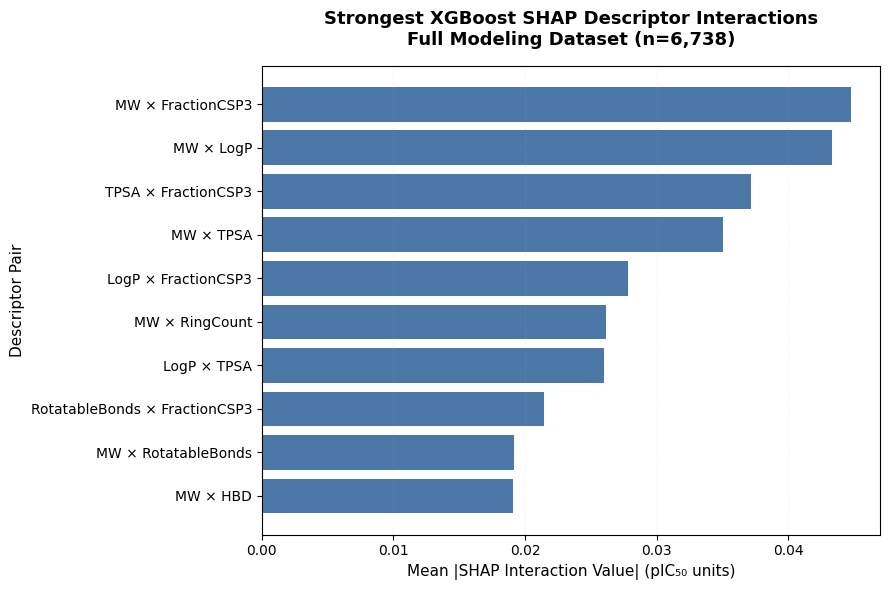


--- Interactions Involving MW, FractionCSP3, or LogP ---


,Rank,Descriptor_1,Descriptor_2,MeanAbsInteraction,RelativeInteraction (%)
0,1,MW,FractionCSP3,0.0447,10.4
1,2,MW,LogP,0.0433,10.1
2,3,TPSA,FractionCSP3,0.0372,8.6
3,4,MW,TPSA,0.0350,8.1
4,5,LogP,FractionCSP3,0.0278,6.5
5,6,MW,RingCount,0.0262,6.1
6,7,LogP,TPSA,0.0260,6.0
7,8,RotatableBonds,FractionCSP3,0.0214,5.0
8,9,MW,RotatableBonds,0.0191,4.4
9,10,MW,HBD,0.0191,4.4



--- Targeted Top-Descriptor Interactions ---


,Rank,Descriptor_1,Descriptor_2,MeanAbsInteraction,RelativeInteraction (%)
0,1,MW,FractionCSP3,0.0447,10.4
1,2,MW,LogP,0.0433,10.1
4,5,LogP,FractionCSP3,0.0278,6.5


In [15]:
# ============================================================
# 5.1 Global SHAP Interaction Analysis
# Full Modeling Dataset (n = 6,738)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap


# ------------------------------------------------------------
# 1. Confirm analysis dataset
# ------------------------------------------------------------

print("--- Global SHAP Interaction Analysis Dataset ---")
print(f"Compounds:   {len(X_full):,}")
print(f"Descriptors: {X_full.shape[1]}")
print(f"Features:    {list(X_full.columns)}")


# ------------------------------------------------------------
# 2. Create TreeExplainer
# ------------------------------------------------------------

# TreeExplainer allows exact pairwise SHAP interaction values
# to be calculated efficiently for tree-based models.

interaction_explainer = shap.TreeExplainer(xgb_model)


# ------------------------------------------------------------
# 3. Calculate SHAP interaction values
# ------------------------------------------------------------

print("\nCalculating SHAP interaction values...")
print("This may take longer than the standard SHAP calculation.")

shap_interaction_values = (
    interaction_explainer.shap_interaction_values(X_full)
)

shap_interaction_values = np.asarray(
    shap_interaction_values
)

print("SHAP interaction calculation complete.")
print(
    "Interaction matrix dimensions:",
    shap_interaction_values.shape
)


# ------------------------------------------------------------
# 4. Verify expected interaction matrix dimensions
# ------------------------------------------------------------

expected_shape = (
    len(X_full),
    X_full.shape[1],
    X_full.shape[1]
)

assert shap_interaction_values.shape == expected_shape, (
    "Unexpected SHAP interaction matrix dimensions."
)

print(
    "Expected dimensions confirmed:",
    expected_shape
)


# ------------------------------------------------------------
# 5. Calculate mean absolute SHAP interaction matrix
# ------------------------------------------------------------

# Each [i, j] element represents the average absolute
# interaction contribution between descriptors i and j.
#
# IMPORTANT:
# Diagonal elements represent main effects, not pairwise
# interactions. They will therefore be excluded when ranking
# descriptor pairs.

mean_abs_interaction = np.mean(
    np.abs(shap_interaction_values),
    axis=0
)

interaction_matrix_df = pd.DataFrame(
    mean_abs_interaction,
    index=X_full.columns,
    columns=X_full.columns
)


# ------------------------------------------------------------
# 6. Extract all unique pairwise interactions
# ------------------------------------------------------------

interaction_records = []

features = list(X_full.columns)

for i in range(len(features)):
    for j in range(i + 1, len(features)):

        interaction_records.append({
            'Descriptor_1': features[i],
            'Descriptor_2': features[j],
            'MeanAbsInteraction': mean_abs_interaction[i, j]
        })


interaction_rank_df = pd.DataFrame(
    interaction_records
)


# ------------------------------------------------------------
# 7. Rank interactions from strongest to weakest
# ------------------------------------------------------------

interaction_rank_df = (
    interaction_rank_df
    .sort_values(
        'MeanAbsInteraction',
        ascending=False
    )
    .reset_index(drop=True)
)

interaction_rank_df['Rank'] = (
    np.arange(1, len(interaction_rank_df) + 1)
)


# ------------------------------------------------------------
# 8. Calculate relative interaction importance
# ------------------------------------------------------------

total_pairwise_interaction = (
    interaction_rank_df['MeanAbsInteraction'].sum()
)

interaction_rank_df['RelativeInteraction (%)'] = (
    interaction_rank_df['MeanAbsInteraction']
    / total_pairwise_interaction
    * 100
)


# Reorder columns
interaction_rank_df = interaction_rank_df[
    [
        'Rank',
        'Descriptor_1',
        'Descriptor_2',
        'MeanAbsInteraction',
        'RelativeInteraction (%)'
    ]
]


# ------------------------------------------------------------
# 9. Display complete interaction ranking
# ------------------------------------------------------------

print("\n--- Global Pairwise SHAP Interaction Ranking ---")

display(
    interaction_rank_df.style.format({
        'MeanAbsInteraction': '{:.4f}',
        'RelativeInteraction (%)': '{:.1f}'
    })
)


# ------------------------------------------------------------
# 10. Display strongest interactions separately
# ------------------------------------------------------------

top_n = 10

top_interactions = interaction_rank_df.head(top_n).copy()

print(f"\n--- Top {top_n} SHAP Descriptor Interactions ---")

display(
    top_interactions.style.format({
        'MeanAbsInteraction': '{:.4f}',
        'RelativeInteraction (%)': '{:.1f}'
    })
)


# ------------------------------------------------------------
# 11. Create interaction labels for plotting
# ------------------------------------------------------------

top_interactions['Interaction'] = (
    top_interactions['Descriptor_1']
    + ' × '
    + top_interactions['Descriptor_2']
)


# Reverse order so strongest interaction appears at the top
plot_df = top_interactions.iloc[::-1]


# ------------------------------------------------------------
# 12. Plot strongest pairwise interactions
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df['Interaction'],
    plot_df['MeanAbsInteraction'],
    color=COLOR_PRIMARY
)

plt.xlabel(
    "Mean |SHAP Interaction Value| (pIC₅₀ units)",
    fontsize=11
)

plt.ylabel(
    "Descriptor Pair",
    fontsize=11
)

plt.title(
    "Strongest XGBoost SHAP Descriptor Interactions\n"
    "Full Modeling Dataset (n=6,738)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    axis='x',
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. Report interactions involving the three dominant
#     descriptors
# ------------------------------------------------------------

dominant_descriptors = [
    'MW',
    'FractionCSP3',
    'LogP'
]

dominant_interactions = interaction_rank_df[
    interaction_rank_df['Descriptor_1'].isin(dominant_descriptors)
    | interaction_rank_df['Descriptor_2'].isin(dominant_descriptors)
].copy()

print(
    "\n--- Interactions Involving MW, FractionCSP3, or LogP ---"
)

display(
    dominant_interactions.style.format({
        'MeanAbsInteraction': '{:.4f}',
        'RelativeInteraction (%)': '{:.1f}'
    })
)


# ------------------------------------------------------------
# 14. Identify the three targeted interactions directly
# ------------------------------------------------------------

target_pairs = [
    {'MW', 'FractionCSP3'},
    {'MW', 'LogP'},
    {'FractionCSP3', 'LogP'}
]

target_mask = interaction_rank_df.apply(
    lambda row: {
        row['Descriptor_1'],
        row['Descriptor_2']
    } in target_pairs,
    axis=1
)

target_interactions = (
    interaction_rank_df[target_mask]
    .sort_values('Rank')
)

print(
    "\n--- Targeted Top-Descriptor Interactions ---"
)

display(
    target_interactions.style.format({
        'MeanAbsInteraction': '{:.4f}',
        'RelativeInteraction (%)': '{:.1f}'
    })
)

#### Global SHAP Interaction Results

The global SHAP interaction analysis demonstrates that the XGBoost model uses meaningful combinations of molecular properties rather than treating the seven descriptors as entirely independent contributors to predicted Nav1.7 inhibitory potency.

The strongest pairwise interaction was **MW × Fraction Csp³**, with a mean absolute SHAP interaction value of **0.0447 pIC₅₀ units**, accounting for approximately **10.4% of the summed pairwise interaction strength**. The second strongest interaction, **MW × LogP**, was nearly equivalent at **0.0433 pIC₅₀ units (10.1%)**. These results indicate that the contribution associated with molecular size depends substantially on both three-dimensional carbon character and lipophilicity.

The third strongest interaction was **TPSA × Fraction Csp³** at **0.0372 pIC₅₀ units (8.6%)**, followed by **MW × TPSA** at **0.0350 pIC₅₀ units (8.1%)**. This is notable because TPSA showed a comparatively weak and context-dependent directional pattern in its individual SHAP dependence analysis. Its high interaction ranking suggests that molecular polarity may become more informative when considered together with other molecular properties rather than as an isolated descriptor.

The interaction between **LogP × Fraction Csp³** ranked fifth, contributing **0.0278 pIC₅₀ units (6.5%)** of summed pairwise interaction strength. Thus, all three pairwise combinations among the globally dominant descriptors—MW, Fraction Csp³, and LogP—appear among the five strongest interactions in the model.

MW participates in six of the ten strongest interactions, reinforcing its central role in the nonlinear model. However, these results also demonstrate that MW should not be interpreted simply as an independent molecular-size effect. Its predictive contribution is partly conditioned by other characteristics including Fraction Csp³, LogP, TPSA, Ring Count, Rotatable Bonds, and HBD.

Overall, the interaction analysis supports a view of Nav1.7 potency prediction based on **combinations of physicochemical properties rather than isolated descriptor optimization**. In particular, molecular size appears most informative when interpreted together with three-dimensional carbon character and lipophilicity, while the strong TPSA × Fraction Csp³ interaction reveals an additional relationship that warrants detailed investigation.

### 5.2 MW × Fraction Csp³ Interaction Analysis

The global SHAP interaction analysis identified **MW × Fraction Csp³ as the strongest pairwise interaction in the XGBoost model**, with a mean absolute SHAP interaction value of **0.0447 pIC₅₀ units**, representing approximately **10.4% of the summed pairwise interaction strength**.

Individually, MW and Fraction Csp³ were also the two most influential descriptors in the global SHAP analysis. The descriptor-specific dependence analyses showed that higher MW values become increasingly favorable after a nonlinear transition, while higher Fraction Csp³ values—particularly above the intermediate range—are associated with increasingly positive contributions to predicted pIC₅₀. The strong interaction between these descriptors indicates that these two relationships cannot be interpreted entirely independently.

This section therefore examines how the model-derived influence of **molecular size changes across different levels of sp³ carbon character**, and conversely whether the effect associated with Fraction Csp³ depends on molecular weight.

The analysis focuses on several questions:

- Does increasing MW produce the same contribution in molecules with low and high Fraction Csp³?
- Is the favorable contribution associated with higher Fraction Csp³ concentrated within particular molecular-weight ranges?
- Are there combinations of MW and Fraction Csp³ associated with especially favorable or unfavorable model contributions?
- Can the interaction explain part of the vertical SHAP variation observed in the individual MW and Fraction Csp³ dependence plots?

Because MW and Fraction Csp³ describe broad and partially overlapping aspects of molecular architecture, the interaction is interpreted as a **model-derived relationship between molecular size and three-dimensional carbon character**, rather than evidence that independently increasing either property will necessarily improve Nav1.7 inhibitory potency.

Identifying well-supported regions of this two-dimensional descriptor space may nevertheless generate useful hypotheses about combinations of molecular size and structural character that warrant deeper structure–activity investigation.

--- MW × Fraction Csp3 Interaction Dataset ---
Compounds: 6,738

Mean |MW × FractionCSP3 interaction|: 0.0447 pIC₅₀ units

--- Fraction Csp3 Quartile Boundaries ---
25th percentile: 0.080
Median:          0.190
75th percentile: 0.308

--- MW × Fraction Csp3 Interaction by Csp3 Quartile ---


,FractionCSP3_Group,CompoundCount,MeanInteraction,MeanAbsInteraction
0,Q1: Lowest Csp³,"1,721",0.0163,0.0523
1,Q2,"1,722",0.0106,0.0177
2,Q3,"1,611",0.0064,0.0230
3,Q4: Highest Csp³,"1,684",0.0187,0.0854


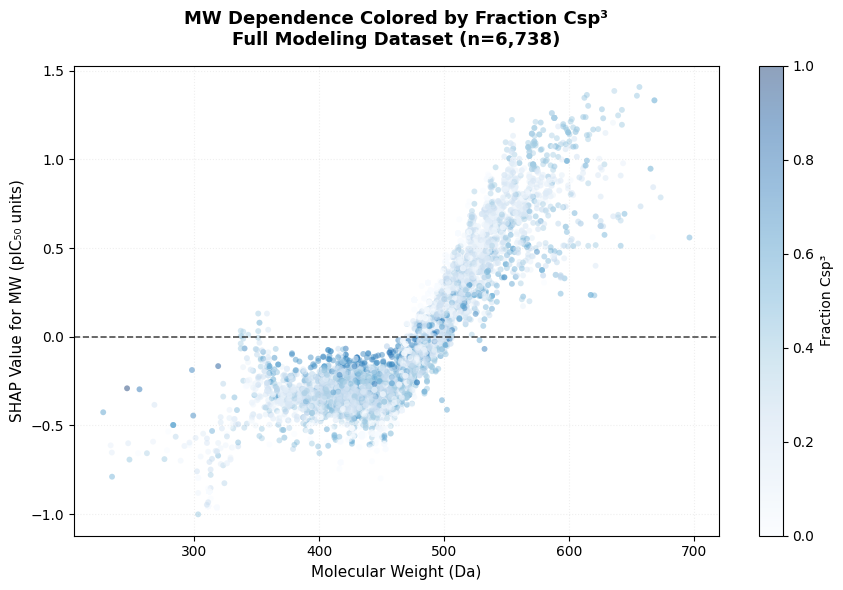

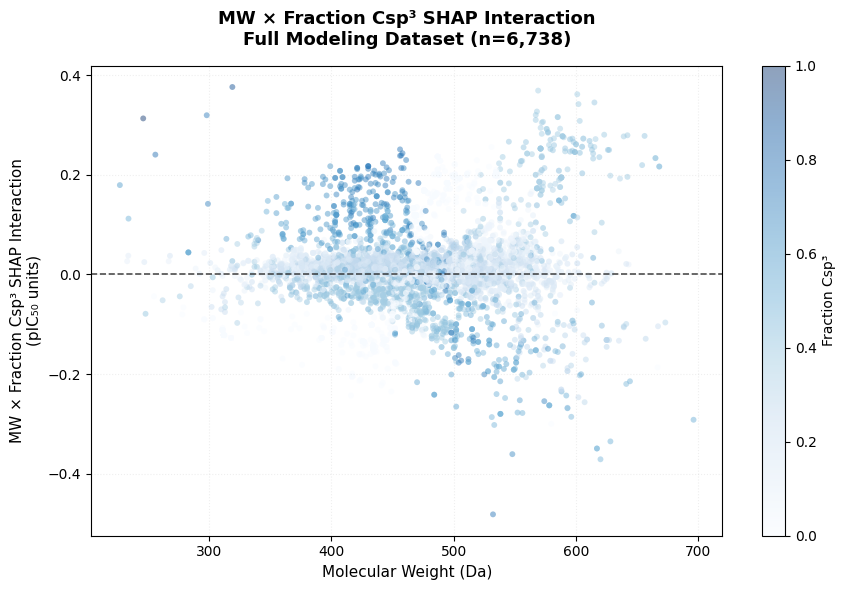


--- Interaction Direction ---
Positive interactions: 4,501 (66.8%)
Negative interactions: 2,237 (33.2%)


In [16]:
# ============================================================
# 5.2 MW × Fraction Csp3 Interaction Analysis
# Full Modeling Dataset (n = 6,738)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Identify descriptor indices
# ------------------------------------------------------------

mw_index = X_full.columns.get_loc('MW')
fcsp3_index = X_full.columns.get_loc('FractionCSP3')


# ------------------------------------------------------------
# 2. Extract descriptor values and SHAP quantities
# ------------------------------------------------------------

mw_values = X_full['MW'].values
fcsp3_values = X_full['FractionCSP3'].values

# Total SHAP contribution assigned to MW
mw_shap = shap_values_full.values[:, mw_index]

# Pairwise MW × FractionCSP3 SHAP interaction contribution
mw_fcsp3_interaction = shap_interaction_values[
    :,
    mw_index,
    fcsp3_index
]


# ------------------------------------------------------------
# 3. Create structured interaction DataFrame
# ------------------------------------------------------------

mw_fcsp3_df = pd.DataFrame({
    'MW': mw_values,
    'FractionCSP3': fcsp3_values,
    'SHAP_MW': mw_shap,
    'Interaction_SHAP': mw_fcsp3_interaction
})


print("--- MW × Fraction Csp3 Interaction Dataset ---")
print(f"Compounds: {len(mw_fcsp3_df):,}")

print(
    "\nMean |MW × FractionCSP3 interaction|: "
    f"{np.mean(np.abs(mw_fcsp3_interaction)):.4f} pIC₅₀ units"
)


# ------------------------------------------------------------
# 4. Define FractionCSP3 groups using quartiles
# ------------------------------------------------------------

fcsp3_q25 = mw_fcsp3_df['FractionCSP3'].quantile(0.25)
fcsp3_q50 = mw_fcsp3_df['FractionCSP3'].quantile(0.50)
fcsp3_q75 = mw_fcsp3_df['FractionCSP3'].quantile(0.75)

print("\n--- Fraction Csp3 Quartile Boundaries ---")
print(f"25th percentile: {fcsp3_q25:.3f}")
print(f"Median:          {fcsp3_q50:.3f}")
print(f"75th percentile: {fcsp3_q75:.3f}")


mw_fcsp3_df['FractionCSP3_Group'] = pd.cut(
    mw_fcsp3_df['FractionCSP3'],
    bins=[
        -np.inf,
        fcsp3_q25,
        fcsp3_q50,
        fcsp3_q75,
        np.inf
    ],
    labels=[
        'Q1: Lowest Csp³',
        'Q2',
        'Q3',
        'Q4: Highest Csp³'
    ],
    include_lowest=True
)


# ------------------------------------------------------------
# 5. Summarize interaction by FractionCSP3 quartile
# ------------------------------------------------------------

fcsp3_interaction_summary = (
    mw_fcsp3_df
    .groupby(
        'FractionCSP3_Group',
        observed=True
    )
    .agg(
        CompoundCount=('Interaction_SHAP', 'size'),
        MeanInteraction=('Interaction_SHAP', 'mean'),
        MeanAbsInteraction=(
            'Interaction_SHAP',
            lambda x: np.mean(np.abs(x))
        )
    )
    .reset_index()
)

print("\n--- MW × Fraction Csp3 Interaction by Csp3 Quartile ---")

display(
    fcsp3_interaction_summary.style.format({
        'CompoundCount': '{:,}',
        'MeanInteraction': '{:.4f}',
        'MeanAbsInteraction': '{:.4f}'
    })
)


# ============================================================
# FIGURE 1
# MW SHAP Dependence Colored by Fraction Csp3
# ============================================================

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    mw_fcsp3_df['MW'],
    mw_fcsp3_df['SHAP_MW'],
    c=mw_fcsp3_df['FractionCSP3'],
    cmap='Blues',
    s=18,
    alpha=0.45,
    edgecolors='none'
)

plt.axhline(
    y=0,
    color=COLOR_ERROR,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8
)

cbar = plt.colorbar(scatter)

cbar.set_label(
    'Fraction Csp³',
    fontsize=10
)

plt.xlabel(
    'Molecular Weight (Da)',
    fontsize=11
)

plt.ylabel(
    'SHAP Value for MW (pIC₅₀ units)',
    fontsize=11
)

plt.title(
    'MW Dependence Colored by Fraction Csp³\n'
    'Full Modeling Dataset (n=6,738)',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2
# Direct MW × Fraction Csp3 SHAP Interaction
# ============================================================

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    mw_fcsp3_df['MW'],
    mw_fcsp3_df['Interaction_SHAP'],
    c=mw_fcsp3_df['FractionCSP3'],
    cmap='Blues',
    s=18,
    alpha=0.45,
    edgecolors='none'
)

plt.axhline(
    y=0,
    color=COLOR_ERROR,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8
)

cbar = plt.colorbar(scatter)

cbar.set_label(
    'Fraction Csp³',
    fontsize=10
)

plt.xlabel(
    'Molecular Weight (Da)',
    fontsize=11
)

plt.ylabel(
    'MW × Fraction Csp³ SHAP Interaction\n(pIC₅₀ units)',
    fontsize=11
)

plt.title(
    'MW × Fraction Csp³ SHAP Interaction\n'
    'Full Modeling Dataset (n=6,738)',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(
    alpha=0.2,
    linestyle=':'
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Identify strongest positive and negative interaction
#    regions without claiming biological thresholds
# ------------------------------------------------------------

positive_interactions = mw_fcsp3_df[
    mw_fcsp3_df['Interaction_SHAP'] > 0
]

negative_interactions = mw_fcsp3_df[
    mw_fcsp3_df['Interaction_SHAP'] < 0
]

print("\n--- Interaction Direction ---")

print(
    f"Positive interactions: "
    f"{len(positive_interactions):,} "
    f"({len(positive_interactions) / len(mw_fcsp3_df):.1%})"
)

print(
    f"Negative interactions: "
    f"{len(negative_interactions):,} "
    f"({len(negative_interactions) / len(mw_fcsp3_df):.1%})"
)

#### MW × Fraction Csp³ Interaction Results

The MW × Fraction Csp³ analysis confirms that the influence of molecular weight on XGBoost predictions depends substantially on the molecule's degree of sp³ carbon character.

The interaction is strongest among compounds in the **highest Fraction Csp³ quartile (>0.308)**, which shows a mean absolute interaction contribution of **0.0854 pIC₅₀ units**. This is substantially larger than the corresponding interaction strength in the two middle Fraction Csp³ quartiles. The lowest Fraction Csp³ quartile also shows appreciable interaction strength (**0.0523 pIC₅₀ units**), indicating that the relationship between molecular size and predicted potency is particularly context-dependent at the extremes of sp³ character.

The direct SHAP interaction plot further demonstrates that the interaction is not uniformly positive or negative. Instead, both the **magnitude and direction** of the MW × Fraction Csp³ interaction change across molecular-weight and Fraction Csp³ space.

Among molecules in approximately the **400–450 Da region**, higher Fraction Csp³ values frequently produce positive MW × Fraction Csp³ interaction contributions. In contrast, within approximately the **500–600 Da region**, many high-Fraction Csp³ compounds show negative interaction contributions, while lower-Fraction Csp³ compounds can show positive contributions. This reversal demonstrates that the two descriptors do not simply reinforce one another across the entire chemical range.

Importantly, a negative interaction contribution does not mean that a compound is predicted to have low potency or that either MW or Fraction Csp³ is individually unfavorable. SHAP interaction values represent the additional contribution arising from the **combination of the two properties beyond their individual main effects**. Thus, a molecule may receive strongly positive individual MW and Fraction Csp³ contributions while simultaneously receiving a negative interaction contribution if their combination produces less benefit than would be expected from their separate effects.

The interaction-colored MW dependence plot also helps explain the substantial vertical dispersion observed in the original MW dependence analysis. Compounds with similar molecular weights can receive different MW contributions depending partly on their Fraction Csp³ values, demonstrating that molecular size is interpreted by the nonlinear model within a broader structural context.

Overall, the strongest pairwise interaction in the model does not define a simple rule such as "larger and more sp³-rich molecules are always favored." Instead, the results reveal a **conditional relationship between molecular size and three-dimensional carbon character**, with particularly strong interaction effects at the extremes of Fraction Csp³ and changes in interaction direction across molecular-weight regions. This behavior provides a model-derived hypothesis that the structural consequences of increasing molecular size depend on how that size is achieved within the molecular architecture.